# Extraction et nettoyage des données GDELT

Objectifs:

1- Extraire les données jugées importantes de des bases de data_event (du 1er janvier au 31 decembre 2025) et gkg

2- Analyser les événements liés au Bénin et détecter les signaux de crise.

Problème identifié :
Présence d’un bruit géographique important lié à "Benin City" qui vient du Nigeria, qui peut fausser les résultats.

Approche :
1. Analyse brute des données
2. Détection du bruit
3. Nettoyage
4. Comparaison avant / après
5. Création d'un nouveau data set sans les bruits

# Librairies et packages

In [820]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Chargement des données

Les fichiers sont chargés directement depuis le repository GitHub afin de garantir la reproductibilité du notebook, indépendamment de l’environnement d’exécution.

In [821]:
#Création de la fonction de chargement de fichier

base_url = "https://raw.githubusercontent.com/cdg33k/HackathonIsheero_Groupe_11/main/data/"

def load_data(filename):
    return pd.read_csv(base_url + filename)

In [822]:
# Chargement des données extraites de GCP

events = load_data("data_event.csv")
gkg = load_data("gkg.csv")

# Jointure table events et gkg

In [823]:
# Vérification avant jointure
print(f"Events : {events.shape}")
print(f"GKG    : {gkg.shape}")
print(f"Colonnes Events : {events.columns.tolist()}")
print(f"Colonnes GKG    : {gkg.columns.tolist()}")

Events : (10884, 21)
GKG    : (8367, 3)
Colonnes Events : ['GLOBALEVENTID', 'SQLDATE', 'ActionGeo_FullName', 'ActionGeo_Lat', 'ActionGeo_Long', 'Actor1Geo_ADM1Code', 'AvgTone', 'NumArticles', 'NumSources', 'QuadClass', 'Actor1Name', 'Actor2Name', 'SOURCEURL', 'GoldsteinScale', 'EventRootCode', 'Actor1Type1Code', 'Actor2Type1Code', 'NumMentions', 'Actor1CountryCode', 'Actor2CountryCode', 'DATEADDED']
Colonnes GKG    : ['DocumentIdentifier', 'Themes', 'SourceCommonName']


In [824]:
# Jointure sur SOURCEURL = DocumentIdentifier
data_final = events.merge(
    gkg,
    left_on='SOURCEURL',
    right_on='DocumentIdentifier',
    how='left'
).drop(columns=['DocumentIdentifier'])

In [825]:
# Vérification
print(f"Dataset final : {data_final.shape}")
print(f"Articles avec thèmes    : {data_final['Themes'].notna().sum()}")
print(f"Articles sans thèmes    : {data_final['Themes'].isna().sum()}")

Dataset final : (10895, 23)
Articles avec thèmes    : 10670
Articles sans thèmes    : 225


In [826]:
# Sauvegarde
data_final.to_csv('data_final.csv', index=False)
print("Fichier sauvegardé : data_final.csv")

Fichier sauvegardé : data_final.csv


In [827]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10895 entries, 0 to 10894
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GLOBALEVENTID       10895 non-null  int64  
 1   SQLDATE             10895 non-null  int64  
 2   ActionGeo_FullName  10895 non-null  object 
 3   ActionGeo_Lat       10895 non-null  float64
 4   ActionGeo_Long      10895 non-null  float64
 5   Actor1Geo_ADM1Code  9466 non-null   object 
 6   AvgTone             10895 non-null  float64
 7   NumArticles         10895 non-null  int64  
 8   NumSources          10895 non-null  int64  
 9   QuadClass           10895 non-null  int64  
 10  Actor1Name          9466 non-null   object 
 11  Actor2Name          7120 non-null   object 
 12  SOURCEURL           10895 non-null  object 
 13  GoldsteinScale      10895 non-null  float64
 14  EventRootCode       10895 non-null  int64  
 15  Actor1Type1Code     4860 non-null   object 
 16  Acto

# Mapping domaine événements

In [828]:
# Regroupement des thèmes/domaine
Domaine_MAPPING = {
    'Politique & Gouvernance' : [
        'USPEC_POLITICS_GENERAL', 'GENERAL_GOVERNMENT', 'LEADER',
        'LEGISLATION', 'WB_831_GOVERNANCE', 'WB_696_PUBLIC_SECTOR',
        'WB_832_ANTI_CORRUPTION', 'WB_678_DIGITAL_GOVERNMENT',
        'ELECTION', 'TAX_FNCACT_PRESIDENT', 'TAX_FNCACT_MINISTER',
        'USPEC_POLICY',
        'CONSTITUTIONAL', 'DEMOCRACY', 'TAX_FNCACT_GOVERNOR',
        'TAX_FNCACT_CHAIRMAN', 'TAX_FNCACT_AUTHORITIES',
        'TAX_FNCACT_CHIEFS_OF_STAFF', 'TAX_FNCACT_COMPTROLLER'
    ],
    'Sécurité & Conflit' : [
        'ARMEDCONFLICT', 'KILL', 'ARREST', 'SECURITY_SERVICES',
        'CRISISLEX_C07_SAFETY', 'CRISISLEX_T03_DEAD', 'CRISISLEX_T02_INJURED',
        'WB_2432_FRAGILITY_CONFLICT', 'WB_2433_CONFLICT_AND_VIOLENCE',
        'TAX_FNCACT_POLICE', 'TAX_MILITARY_TITLE', 'MANMADE_DISASTER_IMPLIED',
        'SOC_GENERALCRIME', 'WB_1014_CRIMINAL_JUSTICE', 'TRIAL',
        'MILITARY', 'BORDER', 'TAX_FNCACT_SOLDIERS',
        'AVIATION_INCIDENT', 'MANMADE_DISASTER'
    ],
    'Économie' : [
        'EPU_ECONOMY', 'EPU_POLICY', 'TAX_ECON_PRICE',
        'WB_1921_PRIVATE_SECTOR', 'WB_2670_JOBS', 'EPU_ECONOMY_HISTORIC',
        'WB_698_TRADE', 'WB_2936_GOLD', 'WB_507_ENERGY',
        'WB_895_MINING', 'WB_1699_METAL', 'TAX_FNCACT_TRADERS',
        'TAX_FNCACT_CASHIER'
    ],
    'Santé' : [
        'GENERAL_HEALTH', 'MEDICAL', 'TAX_DISEASE',
        'WB_621_HEALTH', 'WB_635_PUBLIC_HEALTH',
        'CRISISLEX_C03_WELLBEING_HEALTH'
    ],
    'Éducation & Social' : [
        'EDUCATION', 'WB_470_EDUCATION', 'SOC_POINTSOFINTEREST',
        'CRISISLEX_CRISISLEXREC',
        'TAX_FNCACT_STUDENTS', 'TAX_FNCACT_CITIZENS',
        'TAX_FNCACT_WOMEN', 'TAX_FNCACT_CHILDREN',
        'TAX_FNCACT_ARTISTS', 'FOOD_SECURITY', 'UNGP_FORESTS_RIVERS_OCEANS'
    ],
    'Médias & Communication' : [
        'MEDIA_MSM', 'WB_694_BROADCAST', 'WB_133_INFORMATION',
        'TAX_WORLDLANGUAGES'
    ],
    'Migration' : [
        'EPU_CATS_MIGRATION'
    ],
    'Environnement & Catastrophes' : [
        'NATURAL_DISASTER', 'CRISISLEX_O01_WEATHER',
        'CRISISLEX_T01_CAUTION', 'NATURAL_DISASTER_FLOODING',
        'CRISIS', 'UNGP_FORESTS_RIVERS_OCEANS'
    ]
}

def extraire_domaine(themes_str):
    if pd.isna(themes_str):
        return 'Autre'
    themes_str = themes_str.upper()
    for theme, mots_cles in Domaine_MAPPING.items():
        for mot in mots_cles:
            if mot in themes_str:
                return theme
    return 'Autre'

In [829]:
# Application
data_final['Domaine'] = data_final['Themes'].apply(extraire_domaine)
print(data_final[['SourceCommonName', 'Domaine', 'Themes']])

             SourceCommonName                  Domaine  \
0        africatopsuccess.com  Politique & Gouvernance   
1        diaridetarragona.com       Sécurité & Conflit   
2               allafrica.com  Politique & Gouvernance   
3                   thesun.ng  Politique & Gouvernance   
4                  senego.com  Politique & Gouvernance   
...                       ...                      ...   
10890  lanouvelletribune.info  Politique & Gouvernance   
10891   thenewsnigeria.com.ng  Politique & Gouvernance   
10892    levenementprecis.com  Politique & Gouvernance   
10893             malijet.com  Politique & Gouvernance   
10894              senego.com  Politique & Gouvernance   

                                                  Themes  
0      ARREST;SOC_POINTSOFINTEREST;SOC_POINTSOFINTERE...  
1      EPU_CATS_MIGRATION_FEAR_FEAR;UNGP_FORESTS_RIVE...  
2      EPU_ECONOMY;EPU_ECONOMY_HISTORIC;WB_2024_ANTI_...  
3      EPU_POLICY;EPU_POLICY_POLITICAL;ECON_BOYCOTT;T...  
4      W

In [830]:
# Distribution des événements par domaine
print("Distribution des événements par domaine :")
print(data_final['Domaine'].value_counts())
print()

Distribution des événements par domaine :
Domaine
Politique & Gouvernance         9891
Sécurité & Conflit               465
Autre                            230
Économie                         117
Éducation & Social                97
Médias & Communication            55
Santé                             39
Environnement & Catastrophes       1
Name: count, dtype: int64



Commentaires :
Économie à 117 et Santé à 39 (très faibles) : le Bénin économique est quasi absent de la couverture médiatique internationale
Sécurité & Conflit à 465 : deuxième thème le plus représenté
Politique & Gouvernance à 9883 (presque 90% des données) : c'est en partie normal car beaucoup de tags GDELT ont une connotation politique par défaut

Conclusion : la couverture internationale du Bénin est à 90% politique. L'économie, la santé et le social sont quasi invisibles dans les médias mondiaux.

In [831]:
# Vérification des themes classées "Autre"
autres = data_final[data_final['Domaine'] == 'Autre'][['Themes']].dropna()
if len(autres) > 0:
    print(f"\n{len(autres)} lignes classées 'Autre' :")
    for themes in autres['Themes'].values:
        print(f"  {themes[:100]}")


5 lignes classées 'Autre' :
  TAX_FNCACT;TAX_FNCACT_MAN;
  TAX_FNCACT;TAX_FNCACT_PRINCE;TAX_FNCACT_FATHER;TAX_FNCACT_KING;TAX_FNCACT_CHILD;TAX_FNCACT_INSIDERS;
  TAX_FNCACT;TAX_FNCACT_PRINCE;TAX_FNCACT_FATHER;TAX_FNCACT_KING;TAX_FNCACT_CHILD;TAX_FNCACT_INSIDERS;
  TAX_FNCACT;TAX_FNCACT_MAN;
  SELF_IDENTIFIED_HUMAN_RIGHTS;


Des articles n'ont pas de champ Themes du tout. Ce sont les articles présents dans events mais absents de GKG, donc avec Themes = NaN soit 230 événements dans ce cas.

# Origine des médias

In [832]:
# ============================================================
# DICTIONNAIRE MANUEL
# ============================================================

MEDIAS_CONNUS = {
    # AFRIQUE DE L'OUEST
    '24haubenin.info': 'Afrique de l\'Ouest',
    'benininfo.com': 'Afrique de l\'Ouest',
    'bentelevision.com': 'Afrique de l\'Ouest',
    'gouv.bj': 'Afrique de l\'Ouest',
    'lanouvelletribune.info': 'Afrique de l\'Ouest',
    'levenementprecis.com': 'Afrique de l\'Ouest',
    'visages-du-benin.com': 'Afrique de l\'Ouest',
    'la-flamme.org': 'Afrique de l\'Ouest',
    'tamtaminfo.com': 'Afrique de l\'Ouest',
    'telegramme228.com': 'Afrique de l\'Ouest',
    'punchng.com': 'Afrique de l\'Ouest',
    'guardian.ng': 'Afrique de l\'Ouest',
    'thecable.ng': 'Afrique de l\'Ouest',
    'premiumtimesng.com': 'Afrique de l\'Ouest',
    'dailytrust.com': 'Afrique de l\'Ouest',
    'dailypost.ng': 'Afrique de l\'Ouest',
    'channelstv.com': 'Afrique de l\'Ouest',
    'bellanaija.com': 'Afrique de l\'Ouest',
    'pulse.ng': 'Afrique de l\'Ouest',
    'blueprint.ng': 'Afrique de l\'Ouest',
    'thisdaylive.com': 'Afrique de l\'Ouest',
    'leadership.ng': 'Afrique de l\'Ouest',
    'saharareporters.com': 'Afrique de l\'Ouest',
    'ripplesnigeria.com': 'Afrique de l\'Ouest',
    'thenationonlineng.net': 'Afrique de l\'Ouest',
    'arise.tv': 'Afrique de l\'Ouest',
    'icirnigeria.org': 'Afrique de l\'Ouest',
    'thesun.ng': 'Afrique de l\'Ouest',
    'tell.ng': 'Afrique de l\'Ouest',
    'thenet.ng': 'Afrique de l\'Ouest',
    'thewhistler.ng': 'Afrique de l\'Ouest',
    'tv.guardian.ng': 'Afrique de l\'Ouest',
    'naija247news.com': 'Afrique de l\'Ouest',
    'naijanews.com': 'Afrique de l\'Ouest',
    'nairametrics.com': 'Afrique de l\'Ouest',
    'informationng.com': 'Afrique de l\'Ouest',
    'thenewsnigeria.com.ng': 'Afrique de l\'Ouest',
    'nigerianobservernews.com': 'Afrique de l\'Ouest',
    'nigeriasun.com': 'Afrique de l\'Ouest',
    'nigerianeye.com': 'Afrique de l\'Ouest',
    'nigeriaworld.com': 'Afrique de l\'Ouest',
    'newnigerianpolitics.com': 'Afrique de l\'Ouest',
    'onlinenigeria.com': 'Afrique de l\'Ouest',
    'opinionnigeria.com': 'Afrique de l\'Ouest',
    'pmnewsnigeria.com': 'Afrique de l\'Ouest',
    'politicsnigeria.com': 'Afrique de l\'Ouest',
    'truthnigeria.com': 'Afrique de l\'Ouest',
    'tribuneonlineng.com': 'Afrique de l\'Ouest',
    'withinnigeria.com': 'Afrique de l\'Ouest',
    'ynaija.com': 'Afrique de l\'Ouest',
    'nextedition.com.ng': 'Afrique de l\'Ouest',
    'newsdigest.ng': 'Afrique de l\'Ouest',
    'newsverge.com': 'Afrique de l\'Ouest',
    'newtelegraphng.com': 'Afrique de l\'Ouest',
    'peoplesdailyng.com': 'Afrique de l\'Ouest',
    'igberetvnews.com': 'Afrique de l\'Ouest',
    'hallmarknews.com': 'Afrique de l\'Ouest',
    'ladunliadinews.com': 'Afrique de l\'Ouest',
    'statehouse.gov.ng': 'Afrique de l\'Ouest',
    'newsinvestigatorsng.com': 'Afrique de l\'Ouest',
    'theeagleonline.com.ng': 'Afrique de l\'Ouest',
    'gistreel.com': 'Afrique de l\'Ouest',
    'promptnewsonline.com': 'Afrique de l\'Ouest',
    'silverbirdtv.com': 'Afrique de l\'Ouest',
    'asabametro.com': 'Afrique de l\'Ouest',
    'obalandmagazine.com': 'Afrique de l\'Ouest',
    'stelladimokokorkus.com': 'Afrique de l\'Ouest',
    'nationalaccordnewspaper.com': 'Afrique de l\'Ouest',
    'thetidenewsonline.com': 'Afrique de l\'Ouest',
    'thenigerianvoice.com': 'Afrique de l\'Ouest',
    'newstodaynet.com': 'Afrique de l\'Ouest',
    'ghanaweb.com': 'Afrique de l\'Ouest',
    'graphic.com.gh': 'Afrique de l\'Ouest',
    'myjoyonline.com': 'Afrique de l\'Ouest',
    'ghanamma.com': 'Afrique de l\'Ouest',
    'pulse.com.gh': 'Afrique de l\'Ouest',
    'modernghana.com': 'Afrique de l\'Ouest',
    'ghanafa.org': 'Afrique de l\'Ouest',
    'thebftonline.com': 'Afrique de l\'Ouest',
    'thechronicle.com.gh': 'Afrique de l\'Ouest',
    'theheraldghana.com': 'Afrique de l\'Ouest',
    'newsghana.com.gh': 'Afrique de l\'Ouest',
    'businessghana.com': 'Afrique de l\'Ouest',
    'yen.com.gh': 'Afrique de l\'Ouest',
    'gna.org.gh': 'Afrique de l\'Ouest',
    'techcabal.com': 'Afrique de l\'Ouest',
    'tech-ish.com': 'Afrique de l\'Ouest',
    'abidjan.net': 'Afrique de l\'Ouest',
    'fratmat.info': 'Afrique de l\'Ouest',
    'koaci.com': 'Afrique de l\'Ouest',
    'connectionivoirienne.net': 'Afrique de l\'Ouest',
    'ladepechedabidjan.info': 'Afrique de l\'Ouest',
    'icilome.com': 'Afrique de l\'Ouest',
    'republicoftogo.com': 'Afrique de l\'Ouest',
    'lefaso.net': 'Afrique de l\'Ouest',
    'burkina24.com': 'Afrique de l\'Ouest',
    'actuniger.com': 'Afrique de l\'Ouest',
    'lesahel.org': 'Afrique de l\'Ouest',
    'nigerdiaspora.net': 'Afrique de l\'Ouest',
    'journaldumali.com': 'Afrique de l\'Ouest',
    'maliactu.net': 'Afrique de l\'Ouest',
    'malijet.com': 'Afrique de l\'Ouest',
    'maliweb.net': 'Afrique de l\'Ouest',
    'bamada.net': 'Afrique de l\'Ouest',
    'ortm.ml': 'Afrique de l\'Ouest',
    'lequotidien.sn': 'Afrique de l\'Ouest',
    'lesoleil.sn': 'Afrique de l\'Ouest',
    'senenews.com': 'Afrique de l\'Ouest',
    'seneweb.com': 'Afrique de l\'Ouest',
    'senego.com': 'Afrique de l\'Ouest',
    'dakaractu.com': 'Afrique de l\'Ouest',
    'pressafrik.com': 'Afrique de l\'Ouest',
    'leral.net': 'Afrique de l\'Ouest',
    'lesoftonline.net': 'Afrique de l\'Ouest',
    'ouestaf.com': 'Afrique de l\'Ouest',
    'rewmi.com': 'Afrique de l\'Ouest',
    'ndarinfo.com': 'Afrique de l\'Ouest',
    'africaguinee.com': 'Afrique de l\'Ouest',
    'guineematin.com': 'Afrique de l\'Ouest',
    'guineemining.info': 'Afrique de l\'Ouest',
    'kaloumpresse.com': 'Afrique de l\'Ouest',
    'slguardian.org': 'Afrique de l\'Ouest',
    'statehouse.gov.sl': 'Afrique de l\'Ouest',
    'sierraleonetimes.com': 'Afrique de l\'Ouest',
    'thesierraleonetelegraph.com': 'Afrique de l\'Ouest',
    'frontpageafricaonline.com': 'Afrique de l\'Ouest',
    'gnnliberia.com': 'Afrique de l\'Ouest',
    'thenewdawnliberia.com': 'Afrique de l\'Ouest',
    'thepoint.gm': 'Afrique de l\'Ouest',
    'ami.mr': 'Afrique de l\'Ouest',
    'sonapresse.com': 'Afrique de l\'Ouest',

    # PAN-AFRICAIN
    'allafrica.com': 'Panafricain',
    'panapress.com': 'Panafricain',
    'apanews.net': 'Panafricain',
    'africa.com': 'Panafricain',
    'africanews.com': 'Panafricain',
    'afrik.com': 'Panafricain',
    'quicknews-africa.net': 'Panafricain',
    'aciafrica.org': 'Panafricain',
    'afriquesenlutte.org': 'Panafricain',
    'africa-newsroom.com': 'Panafricain',
    'africabusiness.com': 'Panafricain',
    'africaintelligence.com': 'Panafricain',
    'africatopsuccess.com': 'Panafricain',
    'itweb.africa': 'Panafricain',
    'cajnewsafrica.com': 'Panafricain',
    'cisanewsafrica.com': 'Panafricain',
    'medafricatimes.com': 'Panafricain',
    'africanexaminer.com': 'Panafricain',
    'africanmanager.com': 'Panafricain',
    'okayafrica.com': 'Panafricain',
    'esi-africa.com': 'Panafricain',
    'ecofinagency.com': 'Panafricain',
    'financialafrik.com': 'Panafricain',
    'lesafriques.com': 'Panafricain',
    'oeildafrique.com': 'Panafricain',
    'cnbcafrica.com': 'Panafricain',
    'oilreviewafrica.com': 'Panafricain',
    'opportunitiesforafricans.com': 'Panafricain',
    'itnewsafrica.com': 'Panafricain',
    'africalog.com': 'Panafricain',
    'africanewsanalysis.com': 'Panafricain',
    'pambazuka.org': 'Panafricain',
    'africa-confidential.com': 'Panafricain',

    # AFRIQUE CENTRALE
    'cameroon-tribune.cm': 'Afrique Centrale',
    'camer.be': 'Afrique Centrale',
    'cameroun24.net': 'Afrique Centrale',
    'adiac-congo.com': 'Afrique Centrale',
    'mediacongo.net': 'Afrique Centrale',
    'radiookapi.net': 'Afrique Centrale',
    'gabonactu.com': 'Afrique Centrale',
    'gabonews.com': 'Afrique Centrale',
    'infosplusgabon.com': 'Afrique Centrale',
    'alwihdainfo.com': 'Afrique Centrale',
    'journaldebangui.com': 'Afrique Centrale',
    'jornaltropical.st': 'Afrique Centrale',
    'rna.ao': 'Afrique Centrale',

    # AFRIQUE DE L'EST
    'standardmedia.co.ke': 'Afrique de l\'Est',
    'capitalfm.co.ke': 'Afrique de l\'Est',
    'nairobiwire.com': 'Afrique de l\'Est',
    'citizen.digital': 'Afrique de l\'Est',
    'dailynews.co.tz': 'Afrique de l\'Est',
    'ena.et': 'Afrique de l\'Est',
    'capitalethiopia.com': 'Afrique de l\'Est',
    'newsmada.com': 'Afrique de l\'Est',
    'kachwanya.com': 'Afrique de l\'Est',
    'maravipost.com': 'Afrique de l\'Est',
    'tanzanianewsreports.com': 'Afrique de l\'Est',

    # AFRIQUE AUSTRALE
    'dailymaverick.co.za': 'Afrique Australe',
    'timeslive.co.za': 'Afrique Australe',
    'citizen.co.za': 'Afrique Australe',
    'ewn.co.za': 'Afrique Australe',
    'defenceweb.co.za': 'Afrique Australe',
    'channelafrica.co.za': 'Afrique Australe',
    'biznews.com': 'Afrique Australe',
    'issafrica.org': 'Afrique Australe',
    'gga.org': 'Afrique Australe',
    'mmegi.bw': 'Afrique Australe',
    'newsday.co.zw': 'Afrique Australe',
    'theindependent.co.zw': 'Afrique Australe',
    'thezimbabwean.co': 'Afrique Australe',
    'zimbabwesituation.com': 'Afrique Australe',
    'thezimbabwemail.com': 'Afrique Australe',
    'bulawayo24.com': 'Afrique Australe',
    'jacarandafm.com': 'Afrique Australe',
    'thesouthafrican.com': 'Afrique Australe',
    'iafrica.com': 'Afrique Australe',
    'enca.com': 'Afrique Australe',

    # MOYEN-ORIENT & AFRIQUE DU NORD
    'aljazeera.com': 'Moyen-Orient & Afrique du Nord',
    'aljazeera.net': 'Moyen-Orient & Afrique du Nord',
    'aljazirahnews.com': 'Moyen-Orient & Afrique du Nord',
    'moroccoworldnews.com': 'Moyen-Orient & Afrique du Nord',
    'h24info.ma': 'Moyen-Orient & Afrique du Nord',
    'lematin.ma': 'Moyen-Orient & Afrique du Nord',
    'lavieeco.com': 'Moyen-Orient & Afrique du Nord',
    'libe.ma': 'Moyen-Orient & Afrique du Nord',
    'lnt.ma': 'Moyen-Orient & Afrique du Nord',
    'fr.le360.ma': 'Moyen-Orient & Afrique du Nord',
    'maghrebemergent.com': 'Moyen-Orient & Afrique du Nord',
    'northafricapost.com': 'Moyen-Orient & Afrique du Nord',
    'leseco.ma': 'Moyen-Orient & Afrique du Nord',
    'aps.dz': 'Moyen-Orient & Afrique du Nord',
    'lecourrier-dalgerie.com': 'Moyen-Orient & Afrique du Nord',
    'elkhabar.com': 'Moyen-Orient & Afrique du Nord',
    'lapresse.tn': 'Moyen-Orient & Afrique du Nord',
    'realites.com.tn': 'Moyen-Orient & Afrique du Nord',
    'leaders.com.tn': 'Moyen-Orient & Afrique du Nord',
    'leconomistemaghrebin.com': 'Moyen-Orient & Afrique du Nord',
    'arabnews.com': 'Moyen-Orient & Afrique du Nord',
    'arabtimesonline.com': 'Moyen-Orient & Afrique du Nord',
    'almanar.com.lb': 'Moyen-Orient & Afrique du Nord',
    'alakhbar.info': 'Moyen-Orient & Afrique du Nord',
    'dohanews.co': 'Moyen-Orient & Afrique du Nord',
    'gulf-times.com': 'Moyen-Orient & Afrique du Nord',
    'okaz.com.sa': 'Moyen-Orient & Afrique du Nord',
    'kuna.net.kw': 'Moyen-Orient & Afrique du Nord',
    'tag911.ae': 'Moyen-Orient & Afrique du Nord',
    'khaleejtimes.com': 'Moyen-Orient & Afrique du Nord',
    'presstv.ir': 'Moyen-Orient & Afrique du Nord',
    'mehrnews.com': 'Moyen-Orient & Afrique du Nord',
    'elfagr.org': 'Moyen-Orient & Afrique du Nord',
    'egyptindependent.com': 'Moyen-Orient & Afrique du Nord',
    'sis.gov.eg': 'Moyen-Orient & Afrique du Nord',
    'shorouknews.com': 'Moyen-Orient & Afrique du Nord',
    'el-balad.com': 'Moyen-Orient & Afrique du Nord',
    'shasha.ps': 'Moyen-Orient & Afrique du Nord',
    'alriyadh.com': 'Moyen-Orient & Afrique du Nord',
    'annaharkw.com': 'Moyen-Orient & Afrique du Nord',
    'alkhabarkw.com': 'Moyen-Orient & Afrique du Nord',
    'vetogate.com': 'Moyen-Orient & Afrique du Nord',
    'qatar-tribune.com': 'Moyen-Orient & Afrique du Nord',
    'thepeninsulaqatar.com': 'Moyen-Orient & Afrique du Nord',
    'kuwaitnews.com': 'Moyen-Orient & Afrique du Nord',
    'hispantv.com': 'Moyen-Orient & Afrique du Nord',
    'balatarin.com': 'Moyen-Orient & Afrique du Nord',
    'zawya.com': 'Moyen-Orient & Afrique du Nord',
    'jpost.com': 'Moyen-Orient & Afrique du Nord',

    # FRANCE & FRANCOPHONIE
    'rfi.fr': 'France & Francophonie',
    'lemonde.fr': 'France & Francophonie',
    'lefigaro.fr': 'France & Francophonie',
    'leparisien.fr': 'France & Francophonie',
    'franceinfo.fr': 'France & Francophonie',
    'lepoint.fr': 'France & Francophonie',
    'lexpress.fr': 'France & Francophonie',
    'jeuneafrique.com': 'France & Francophonie',
    'courrierinternational.com': 'France & Francophonie',
    'challenges.fr': 'France & Francophonie',
    'bfmtv.com': 'France & Francophonie',
    'europe1.fr': 'France & Francophonie',
    'tf1info.fr': 'France & Francophonie',
    'la-croix.com': 'France & Francophonie',
    'latribune.fr': 'France & Francophonie',
    'humanite.fr': 'France & Francophonie',
    'reporterre.net': 'France & Francophonie',
    'nouvelobs.com': 'France & Francophonie',
    'ladepeche.fr': 'France & Francophonie',
    'sudouest.fr': 'France & Francophonie',
    'estrepublicain.fr': 'France & Francophonie',
    'francebleu.fr': 'France & Francophonie',
    'franceguyane.fr': 'France & Francophonie',
    'francetvinfo.fr': 'France & Francophonie',
    'radiofrance.fr': 'France & Francophonie',
    'la1ere.francetvinfo.fr': 'France & Francophonie',
    'la1ere.franceinfo.fr': 'France & Francophonie',
    'presse-citron.net': 'France & Francophonie',
    'actusante.net': 'France & Francophonie',
    'voltairenet.org': 'France & Francophonie',
    'econostrum.info': 'France & Francophonie',
    'linfo.re': 'France & Francophonie',
    'temoignages.re': 'France & Francophonie',
    'afropages.fr': 'France & Francophonie',
    'agoravox.fr': 'France & Francophonie',
    'mondafrique.com': 'France & Francophonie',
    'africapresse.com': 'France & Francophonie',
    'agenceafrique.com': 'France & Francophonie',
    'pourquoidocteur.fr': 'France & Francophonie',
    'santemagazine.fr': 'France & Francophonie',
    'sortiraparis.com': 'France & Francophonie',
    'lyoncapitale.fr': 'France & Francophonie',
    'jhm.fr': 'France & Francophonie',
    'parismatch.com': 'France & Francophonie',
    'lalibre.be': 'France & Francophonie',
    'dhnet.be': 'France & Francophonie',
    'levif.be': 'France & Francophonie',
    'rtl.be': 'France & Francophonie',
    'dewereldmorgen.be': 'France & Francophonie',
    'trends.knack.be': 'France & Francophonie',
    'trends.levif.be': 'France & Francophonie',
    'letemps.ch': 'France & Francophonie',
    'tdg.ch': 'France & Francophonie',
    'rsi.ch': 'France & Francophonie',
    'rts.ch': 'France & Francophonie',
    'lequotidien.lu': 'France & Francophonie',
    'chronicle.lu': 'France & Francophonie',
    'telecran.lu': 'France & Francophonie',
    'lemauricien.com': 'France & Francophonie',
    'alterpresse.org': 'France & Francophonie',
    'icihaiti.com': 'France & Francophonie',
    'haitiantimes.com': 'France & Francophonie',
    'haitilibre.com': 'France & Francophonie',
    'lactualite.com': 'France & Francophonie',
    'journaldemontreal.com': 'France & Francophonie',
    'acadienouvelle.com': 'France & Francophonie',
    'infotel.ca': 'France & Francophonie',
    'enbeauce.com': 'France & Francophonie',
    'guadeloupe.franceantilles.fr': 'France & Francophonie',
    'martinique.franceantilles.fr': 'France & Francophonie',
    'afriquejet.com': 'France & Francophonie',
    'leconomiste.com': 'France & Francophonie',
    'ledauphine.com': 'France & Francophonie',
    'laprovence.com': 'France & Francophonie',
    'varmatin.com': 'France & Francophonie',
    'maville.com': 'France & Francophonie',
    'linternaute.com': 'France & Francophonie',
    'lepointsur.com': 'France & Francophonie',
    'lestimes.com': 'France & Francophonie',
    'lemagazinedumanager.com': 'France & Francophonie',
    'lejecos.com': 'France & Francophonie',
    'topsante.com': 'France & Francophonie',
    'tourmag.com': 'France & Francophonie',
    'routard.com': 'France & Francophonie',
    'zonebourse.com': 'France & Francophonie',

    # EUROPE
    'dw.com': 'Europe',
    'euronews.com': 'Europe',
    'actualno.com': 'Europe',
    'agenzianova.com': 'Europe',
    'cineuropa.org': 'Europe',
    'cronicadecantabria.com': 'Europe',
    'diaridetarragona.com': 'Europe',
    'diariosigloxxi.com': 'Europe',
    'diariovasco.com': 'Europe',
    'efe.com': 'Europe',
    'ekipnews.com': 'Europe',
    'elconfidencialdigital.com': 'Europe',
    'elcorreo.com': 'Europe',
    'elcorreodeburgos.com': 'Europe',
    'eldiadevalladolid.com': 'Europe',
    'elfaradio.com': 'Europe',
    'elpais.com': 'Europe',
    'elperiodicomediterraneo.com': 'Europe',
    'focus-news.net': 'Europe',
    'granadahoy.com': 'Europe',
    'hispanidad.com': 'Europe',
    'ilsole24ore.com': 'Europe',
    'ilsussidiario.net': 'Europe',
    'inewsgr.com': 'Europe',
    'kerkida.net': 'Europe',
    'kosova-sot.info': 'Europe',
    'kuruc.info': 'Europe',
    'lanzadigital.com': 'Europe',
    'lavanguardia.com': 'Europe',
    'laverdadnoticias.com': 'Europe',
    'levante-emv.com': 'Europe',
    'marigliano.net': 'Europe',
    'mundodeportivo.com': 'Europe',
    'notimerica.com': 'Europe',
    'notiziegeopolitiche.net': 'Europe',
    'pupia.tv': 'Europe',
    'romania-insider.com': 'Europe',
    'segabg.com': 'Europe',
    'sigmalive.com': 'Europe',
    'standartnews.com': 'Europe',
    'tag24.com': 'Europe',
    'telegrafi.com': 'Europe',
    'tuttomercatoweb.com': 'Europe',
    'ujszo.com': 'Europe',
    'unita.tv': 'Europe',
    'vozpopuli.com': 'Europe',
    'xataka.com': 'Europe',
    'charter97.org': 'Europe',
    'irishnews.com': 'Europe',
    'irishtimes.com': 'Europe',
    'rte.ie': 'Europe',
    'carlow-nationalist.ie': 'Europe',
    'kildare-nationalist.ie': 'Europe',

    # RUSSIE & CHINE
    'rt.com': 'Russie & Chine',
    'sputnikglobe.com': 'Russie & Chine',
    'sputniknews.africa': 'Russie & Chine',
    'tass.com': 'Russie & Chine',
    'tass.ru': 'Russie & Chine',
    'xinhuanet.com': 'Russie & Chine',
    'english.news.cn': 'Russie & Chine',
    'chinadaily.com.cn': 'Russie & Chine',
    'globaltimes.cn': 'Russie & Chine',
    'people.com.cn': 'Russie & Chine',
    'chinaview.cn': 'Russie & Chine',
    'en.people.cn': 'Russie & Chine',
    'en.ce.cn': 'Russie & Chine',
    'arabic.news.cn': 'Russie & Chine',
    'china.org.cn': 'Russie & Chine',

    # AMÉRIQUE DU NORD
    'bbc.com': 'Amérique du Nord',
    'cnn.com': 'Amérique du Nord',
    'foxnews.com': 'Amérique du Nord',
    'npr.org': 'Amérique du Nord',
    'newsweek.com': 'Amérique du Nord',
    'forbes.com': 'Amérique du Nord',
    'voanews.com': 'Amérique du Nord',
    'voaafrique.com': 'Amérique du Nord',
    'theconversation.com': 'Amérique du Nord',
    'cfr.org': 'Amérique du Nord',
    'heritage.org': 'Amérique du Nord',
    'army.mil': 'Amérique du Nord',
    'usembassy.gov': 'Amérique du Nord',
    'africom.mil': 'Amérique du Nord',
    'harvard.edu': 'Amérique du Nord',
    'bu.edu': 'Amérique du Nord',
    'jhu.edu': 'Amérique du Nord',
    'yale.edu': 'Amérique du Nord',
    'kgou.org': 'Amérique du Nord',
    'kjzz.org': 'Amérique du Nord',
    'knau.org': 'Amérique du Nord',
    'kuow.org': 'Amérique du Nord',
    'wamc.org': 'Amérique du Nord',
    'wbur.org': 'Amérique du Nord',
    'wgbh.org': 'Amérique du Nord',
    'houstonpublicmedia.org': 'Amérique du Nord',
    'northcountrypublicradio.org': 'Amérique du Nord',
    'ualrpublicradio.org': 'Amérique du Nord',
    'wyomingnewsnow.tv': 'Amérique du Nord',
    'ctmirror.org': 'Amérique du Nord',
    'bostonglobe.com': 'Amérique du Nord',
    'latimes.com': 'Amérique du Nord',
    'nypost.com': 'Amérique du Nord',
    'nysun.com': 'Amérique du Nord',
    'newrepublic.com': 'Amérique du Nord',
    'breitbart.com': 'Amérique du Nord',
    'hotair.com': 'Amérique du Nord',
    'glennbeck.com': 'Amérique du Nord',
    'blackagendareport.com': 'Amérique du Nord',
    'blackenterprise.com': 'Amérique du Nord',
    'blackstarnews.com': 'Amérique du Nord',
    'yahoo.com': 'Amérique du Nord',
    'aol.com': 'Amérique du Nord',
    'hollywoodreporter.com': 'Amérique du Nord',
    'deadline.com': 'Amérique du Nord',
    'theglobeandmail.com': 'Amérique du Nord',
    'winnipegfreepress.com': 'Amérique du Nord',
    'cbc.ca': 'Amérique du Nord',

    # ROYAUME-UNI
    'bbc.co.uk': 'Royaume-Uni',
    'theguardian.com': 'Royaume-Uni',
    'independent.co.uk': 'Royaume-Uni',
    'dailymail.co.uk': 'Royaume-Uni',
    'mirror.co.uk': 'Royaume-Uni',
    'sky.com': 'Royaume-Uni',
    'express.co.uk': 'Royaume-Uni',
    'thesun.co.uk': 'Royaume-Uni',
    'spectator.co.uk': 'Royaume-Uni',
    'morningstaronline.co.uk': 'Royaume-Uni',
    'private-eye.co.uk': 'Royaume-Uni',
    'cherwell.org': 'Royaume-Uni',
    'trtworld.com': 'Royaume-Uni',
    'wionews.com': 'Royaume-Uni',
    'sbs.com.au': 'Royaume-Uni',
    'nzherald.co.nz': 'Royaume-Uni',
    'jamaica-gleaner.com': 'Royaume-Uni',
    'jamaicaobserver.com': 'Royaume-Uni',
    'nowgrenada.com': 'Royaume-Uni',
    'stabroeknews.com': 'Royaume-Uni',
    'surinametimes.com': 'Royaume-Uni',

    # ORGANISATIONS INTERNATIONALES
    'fao.org': 'Organisations internationales',
    'undp.org': 'Organisations internationales',
    'unesco.org': 'Organisations internationales',
    'uneca.org': 'Organisations internationales',
    'au.int': 'Organisations internationales',
    'ecowas.int': 'Organisations internationales',
    'ifj.org': 'Organisations internationales',
    'msf.org': 'Organisations internationales',
    'icij.org': 'Organisations internationales',
    'rsf.org': 'Organisations internationales',
    'occrp.org': 'Organisations internationales',
    'idea.int': 'Organisations internationales',
    'ifex.org': 'Organisations internationales',
    'project-syndicate.org': 'Organisations internationales',
    'opengovpartnership.org': 'Organisations internationales',
    'gatesfoundation.org': 'Organisations internationales',
    'afrobarometer.org': 'Organisations internationales',
    'ecdpm.org': 'Organisations internationales',
    'wcoomd.org': 'Organisations internationales',
    'intracen.org': 'Organisations internationales',
    'worldfoodprize.org': 'Organisations internationales',
    'ifdc.org': 'Organisations internationales',
    'fian.org': 'Organisations internationales',
    'icsf.net': 'Organisations internationales',
    'awdf.org': 'Organisations internationales',
    'figo.org': 'Organisations internationales',
    'eurogendfor.org': 'Organisations internationales',
    'eurekalert.org': 'Organisations internationales',
    'borgenproject.org': 'Organisations internationales',
    'globalissues.org': 'Organisations internationales',
    'globalsecurity.org': 'Organisations internationales',
    'justiceinfo.net': 'Organisations internationales',
    'ecfr.eu': 'Organisations internationales',
    'ipsnoticias.net': 'Organisations internationales',
    'ipsnews.net': 'Organisations internationales',
    'osservatoreromano.va': 'Organisations internationales',
    'fides.org': 'Organisations internationales',
    'aacc-ceta.org': 'Organisations internationales',
    'ebrd.com': 'Organisations internationales',
    'globalsistersreport.org': 'Organisations internationales',
    'universityworldnews.com': 'Organisations internationales',
    'globalvoices.org': 'Organisations internationales',

    # AMÉRIQUE LATINE
    'lanacion.com.ar': 'Amérique Latine',
    'pagina12.com.ar': 'Amérique Latine',
    'lavoz.com.ar': 'Amérique Latine',
    'pregon.com.ar': 'Amérique Latine',
    'carasycaretas.com.uy': 'Amérique Latine',
    'bitacora.com.uy': 'Amérique Latine',
    'elobservador.com.uy': 'Amérique Latine',
    'elpais.com.uy': 'Amérique Latine',
    'jornada.com.mx': 'Amérique Latine',
    'proceso.com.mx': 'Amérique Latine',
    'razon.com.mx': 'Amérique Latine',
    'sinembargo.mx': 'Amérique Latine',
    'cuartopoder.mx': 'Amérique Latine',
    'eldiariodechihuahua.mx': 'Amérique Latine',
    'omnia.com.mx': 'Amérique Latine',
    'zocalo.com.mx': 'Amérique Latine',
    'animalpolitico.com': 'Amérique Latine',
    'acento.com.do': 'Amérique Latine',
    'elperiodico.com.do': 'Amérique Latine',
    'diariodigitalrd.com': 'Amérique Latine',
    'lanaciondominicana.com': 'Amérique Latine',
    'noticiassin.com': 'Amérique Latine',
    'noticierodigital.com': 'Amérique Latine',
    'elheraldo.co': 'Amérique Latine',
    'pulzo.com': 'Amérique Latine',
    'diariodelhuila.com': 'Amérique Latine',
    'prensa-latina.cu': 'Amérique Latine',
    'cuba.cu': 'Amérique Latine',
    'telesurtv.net': 'Amérique Latine',
    'rnv.gob.ve': 'Amérique Latine',
    'avn.info.ve': 'Amérique Latine',
    'ultimasnoticias.com.ve': 'Amérique Latine',
    'ciudadccs.info': 'Amérique Latine',
    'aporrea.org': 'Amérique Latine',
    'lapatilla.com': 'Amérique Latine',
    'abc.com.py': 'Amérique Latine',
    'nacion.com': 'Amérique Latine',
    'latercera.com': 'Amérique Latine',
    'globo.com': 'Amérique Latine',
    'infobae.com': 'Amérique Latine',
    'mdzol.com': 'Amérique Latine',
    'eldestapeweb.com': 'Amérique Latine',
    'bolpress.com': 'Amérique Latine',
    'cadena3.com': 'Amérique Latine',
    'radiolaprimerisima.com': 'Amérique Latine',
    'diariolasamericas.com': 'Amérique Latine',
    'diariolibre.com': 'Amérique Latine',
    'elvocero.com': 'Amérique Latine',
    'planoinformativo.com': 'Amérique Latine',

    # ASIE
    'straitstimes.com': 'Asie',
    'scmp.com': 'Asie',
    'yomiuri.co.jp': 'Asie',
    'thejakartapost.com': 'Asie',
    'dawn.com': 'Asie',
    'dawnnews.tv': 'Asie',
    'aaj.tv': 'Asie',
    'express.pk': 'Asie',
    'dailyaaj.com.pk': 'Asie',
    'tribune.com.pk': 'Asie',
    'thenews.com.pk': 'Asie',
    'focustaiwan.tw': 'Asie',
    'taipeitimes.com': 'Asie',
    'en.tempo.co': 'Asie',
    'antaranews.com': 'Asie',
    'manilastandard.net': 'Asie',
    'manilatimes.net': 'Asie',
    'businessmirror.com.ph': 'Asie',
    'philstar.com': 'Asie',
    'thestar.com.my': 'Asie',
    'thesun.my': 'Asie',
    'malaymail.com': 'Asie',
    'borneobulletin.com.bn': 'Asie',
    'theborneopost.com': 'Asie',
    'edaily.co.kr': 'Asie',
    'kmib.co.kr': 'Asie',
    'koreaherald.com': 'Asie',
    'naver.com': 'Asie',
    'busan.com': 'Asie',
    'tbsnews.net': 'Asie',
    'bssnews.net': 'Asie',
    'banglanews24.com': 'Asie',
    'bdnews24.com': 'Asie',
    'jugantor.com': 'Asie',
    'jagonews24.com': 'Asie',
    'lecourrier.vn': 'Asie',
    'news.tuoitre.vn': 'Asie',
    'es.vietnamplus.vn': 'Asie',
    'thehindu.com': 'Asie',
    'thehindubusinessline.com': 'Asie',
    'indianexpress.com': 'Asie',
    'indiatimes.com': 'Asie',
    'ndtv.com': 'Asie',
    'hindustantimes.com': 'Asie',
    'firstpost.com': 'Asie',
    'livemint.com': 'Asie',
    'moneycontrol.com': 'Asie',
    'scroll.in': 'Asie',
    'aninews.in': 'Asie',
    'deccanchronicle.com': 'Asie',
    'maalaimalar.com': 'Asie',
    'mathrubhumi.com': 'Asie',
    'navabharat.com': 'Asie',
    'netindia123.com': 'Asie',
    'news18.com': 'Asie',
    'oneindia.com': 'Asie',
    'jagran.com': 'Asie',
    'morungexpress.com': 'Asie',
    'kreatio.info': 'Asie',
    'tibet.net': 'Asie',
    '1in.am': 'Asie',
    '1news.az': 'Asie',
    'en.apa.az': 'Asie',
    'en.trend.az': 'Asie',
    'haqqin.az': 'Asie',
    'trend.az': 'Asie',
    'ekhokavkaza.com': 'Asie',
    'astanatimes.com': 'Asie',
    'centralasiatimes.com': 'Asie',
    'nationthailand.com': 'Asie',
    'macaubusiness.com': 'Asie',
    'singaporestar.com': 'Asie',
}

# ============================================================
# LES EXTENSIONS NATIONALES
# ============================================================

EXTENSION_REGION = {
    # Afrique de l'Ouest
    '.bj': 'Afrique de l\'Ouest',
    '.ng': 'Afrique de l\'Ouest',
    '.gh': 'Afrique de l\'Ouest',
    '.sn': 'Afrique de l\'Ouest',
    '.ci': 'Afrique de l\'Ouest',
    '.ml': 'Afrique de l\'Ouest',
    '.bf': 'Afrique de l\'Ouest',
    '.ne': 'Afrique de l\'Ouest',
    '.tg': 'Afrique de l\'Ouest',
    '.gn': 'Afrique de l\'Ouest',
    '.sl': 'Afrique de l\'Ouest',
    '.lr': 'Afrique de l\'Ouest',
    '.mr': 'Afrique de l\'Ouest',
    '.gm': 'Afrique de l\'Ouest',
    '.cv': 'Afrique de l\'Ouest',
    # Afrique Centrale
    '.cm': 'Afrique Centrale',
    '.cg': 'Afrique Centrale',
    '.cd': 'Afrique Centrale',
    '.ga': 'Afrique Centrale',
    '.cf': 'Afrique Centrale',
    '.td': 'Afrique Centrale',
    '.ao': 'Afrique Centrale',
    '.gq': 'Afrique Centrale',
    # Afrique de l'Est
    '.ke': 'Afrique de l\'Est',
    '.tz': 'Afrique de l\'Est',
    '.ug': 'Afrique de l\'Est',
    '.et': 'Afrique de l\'Est',
    '.rw': 'Afrique de l\'Est',
    '.bi': 'Afrique de l\'Est',
    '.so': 'Afrique de l\'Est',
    # Afrique Australe
    '.za': 'Afrique Australe',
    '.zw': 'Afrique Australe',
    '.bw': 'Afrique Australe',
    '.mz': 'Afrique Australe',
    '.zm': 'Afrique Australe',
    '.na': 'Afrique Australe',
    '.mw': 'Afrique Australe',
    # Moyen-Orient & Afrique du Nord
    '.ma': 'Moyen-Orient & Afrique du Nord',
    '.dz': 'Moyen-Orient & Afrique du Nord',
    '.tn': 'Moyen-Orient & Afrique du Nord',
    '.eg': 'Moyen-Orient & Afrique du Nord',
    '.ly': 'Moyen-Orient & Afrique du Nord',
    '.il': 'Moyen-Orient & Afrique du Nord',
    '.sa': 'Moyen-Orient & Afrique du Nord',
    '.ae': 'Moyen-Orient & Afrique du Nord',
    '.kw': 'Moyen-Orient & Afrique du Nord',
    '.qa': 'Moyen-Orient & Afrique du Nord',
    '.ir': 'Moyen-Orient & Afrique du Nord',
    '.lb': 'Moyen-Orient & Afrique du Nord',
    # France & Francophonie
    '.fr': 'France & Francophonie',
    '.lu': 'France & Francophonie',
    # Europe
    '.de': 'Europe',
    '.it': 'Europe',
    '.es': 'Europe',
    '.pt': 'Europe',
    '.nl': 'Europe',
    '.pl': 'Europe',
    '.ro': 'Europe',
    '.bg': 'Europe',
    '.gr': 'Europe',
    '.at': 'Europe',
    '.se': 'Europe',
    '.no': 'Europe',
    '.dk': 'Europe',
    '.fi': 'Europe',
    '.cz': 'Europe',
    '.hu': 'Europe',
    '.hr': 'Europe',
    '.rs': 'Europe',
    '.lt': 'Europe',
    '.lv': 'Europe',
    '.ee': 'Europe',
    '.mk': 'Europe',
    '.al': 'Europe',
    '.by': 'Europe',
    '.cy': 'Europe',
    # Russie & Chine
    '.ru': 'Russie & Chine',
    '.cn': 'Russie & Chine',
    # Royaume-Uni
    '.co.uk': 'Royaume-Uni',
    '.uk': 'Royaume-Uni',
    '.ie': 'Royaume-Uni',
    '.au': 'Royaume-Uni',
    '.nz': 'Royaume-Uni',
    # Amérique du Nord
    '.ca': 'Amérique du Nord',
    # Amérique Latine
    '.br': 'Amérique Latine',
    '.mx': 'Amérique Latine',
    '.ar': 'Amérique Latine',
    '.ve': 'Amérique Latine',
    '.co': 'Amérique Latine',
    '.cu': 'Amérique Latine',
    '.uy': 'Amérique Latine',
    '.py': 'Amérique Latine',
    '.bo': 'Amérique Latine',
    '.pe': 'Amérique Latine',
    '.ec': 'Amérique Latine',
    '.cl': 'Amérique Latine',
    '.do': 'Amérique Latine',
    # Asie
    '.in': 'Asie',
    '.jp': 'Asie',
    '.kr': 'Asie',
    '.pk': 'Asie',
    '.id': 'Asie',
    '.my': 'Asie',
    '.ph': 'Asie',
    '.vn': 'Asie',
    '.tw': 'Asie',
    '.bd': 'Asie',
    '.az': 'Asie',
    '.am': 'Asie',
    '.kz': 'Asie',
    '.tr': 'Asie',
    '.sg': 'Asie',
    '.th': 'Asie',
}

# ============================================================
# FONCTION D'ASSIGNATION
# ============================================================

def associer_region(media):
    if pd.isna(media) or media == 'Unknown' or media == '':
        return 'Non identifié'

    media_lower = media.lower()

    # Recours au ictionnaire manuel
    if media in MEDIAS_CONNUS:
        return MEDIAS_CONNUS[media]

    # Recours aux extensions nationales
    for ext, region in sorted(EXTENSION_REGION.items(), key=lambda x: -len(x[0])):
        if media_lower.endswith(ext):
            return region

    # Sites non identifiés
    return 'Non identifié'

In [833]:
# Application sur data_final
data_final['Region'] = data_final['SourceCommonName'].apply(associer_region)

In [834]:
# Vérification
print("Distribution par région :")
print(data_final['Region'].value_counts())

non_assignes = data_final[data_final['Region'] == 'Non identifié']
print(f"\nNon identifiés : {len(non_assignes['SourceCommonName'].unique())}")

Distribution par région :
Region
Afrique de l'Ouest                7073
Panafricain                        962
Non identifié                      690
France & Francophonie              377
Europe                             373
Russie & Chine                     196
Amérique du Nord                   188
Moyen-Orient & Afrique du Nord     179
Asie                               168
Amérique Latine                    144
Royaume-Uni                        137
Organisations internationales      128
Afrique Australe                   124
Afrique de l'Est                    85
Afrique Centrale                    71
Name: count, dtype: int64

Non identifiés : 189


Afrique de l'Ouest domine massivement avec 7073 sur ~10 700 articles. La couverture du Bénin est avant tout régionale, pas vraiment internationale.

France & Francophonie à 377 : c'est la première source extérieure au continent africain. Ce qui est plutôt cohérent avec les liens historiques.

Russie & Chine à 196 soit une présence notable, comparable à l'Amérique du Nord (188)

Afrique du Nord et Moyen-Orient à 179 soit une présence modeste mais réelle des médias arabophones.

# Apperçu du data set actuel

In [835]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10895 entries, 0 to 10894
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GLOBALEVENTID       10895 non-null  int64  
 1   SQLDATE             10895 non-null  int64  
 2   ActionGeo_FullName  10895 non-null  object 
 3   ActionGeo_Lat       10895 non-null  float64
 4   ActionGeo_Long      10895 non-null  float64
 5   Actor1Geo_ADM1Code  9466 non-null   object 
 6   AvgTone             10895 non-null  float64
 7   NumArticles         10895 non-null  int64  
 8   NumSources          10895 non-null  int64  
 9   QuadClass           10895 non-null  int64  
 10  Actor1Name          9466 non-null   object 
 11  Actor2Name          7120 non-null   object 
 12  SOURCEURL           10895 non-null  object 
 13  GoldsteinScale      10895 non-null  float64
 14  EventRootCode       10895 non-null  int64  
 15  Actor1Type1Code     4860 non-null   object 
 16  Acto

In [836]:
# verification des doublons
data_final.duplicated(subset=['GLOBALEVENTID'], keep=False).sum()

np.int64(22)

In [837]:
data_final[data_final['GLOBALEVENTID'].duplicated(keep=False)].sort_values('GLOBALEVENTID')

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,Actor1Geo_ADM1Code,AvgTone,NumArticles,NumSources,QuadClass,...,Actor1Type1Code,Actor2Type1Code,NumMentions,Actor1CountryCode,Actor2CountryCode,DATEADDED,Themes,SourceCommonName,Domaine,Region
6601,1225666226,20250210,Benin,9.50000,2.25000,NaN,1.652893,10,1,1,...,NaN,GOV,10,NaN,NaN,20250210153000,TAX_FNCACT;TAX_FNCACT_MINISTERS;EDUCATION;WB_4...,kaloumpresse.com,Politique & Gouvernance,Afrique de l'Ouest
6602,1225666226,20250210,Benin,9.50000,2.25000,NaN,1.652893,10,1,1,...,NaN,GOV,10,NaN,NaN,20250210153000,TAX_FNCACT;TAX_FNCACT_MINISTERS;LEADER;TAX_FNC...,kaloumpresse.com,Politique & Gouvernance,Afrique de l'Ouest
7054,1225713456,20250210,Benin,9.50000,2.25000,BN,1.210428,10,1,1,...,NaN,ELI,10,AFR,USA,20250210204500,LEADER;TAX_FNCACT;TAX_FNCACT_PRESIDENT;USPEC_P...,heritage.org,Politique & Gouvernance,Amérique du Nord
7053,1225713456,20250210,Benin,9.50000,2.25000,BN,1.210428,10,1,1,...,NaN,ELI,10,AFR,USA,20250210204500,LEADER;TAX_FNCACT;TAX_FNCACT_PRESIDENT;USPEC_P...,heritage.org,Politique & Gouvernance,Amérique du Nord
475,1228794152,20250226,"Savalou, Collines, Benin",7.92807,1.97558,NaN,-4.444444,10,1,4,...,NaN,COP,10,NaN,NaN,20250226040000,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;TA...,lanouvelletribune.info,Sécurité & Conflit,Afrique de l'Ouest
476,1228794152,20250226,"Savalou, Collines, Benin",7.92807,1.97558,NaN,-4.444444,10,1,4,...,NaN,COP,10,NaN,NaN,20250226040000,TAX_FNCACT;TAX_FNCACT_VICTIM;EPU_CATS_MIGRATIO...,lanouvelletribune.info,Sécurité & Conflit,Afrique de l'Ouest
6809,1237266776,20250410,Benin,9.50000,2.25000,NaN,4.524887,2,1,1,...,NaN,NaN,2,NaN,CIV,20250410161500,USPEC_POLICY1;EPU_POLICY;EPU_POLICY_BUDGET;TAX...,koaci.com,Politique & Gouvernance,Afrique de l'Ouest
6810,1237266776,20250410,Benin,9.50000,2.25000,NaN,4.524887,2,1,1,...,NaN,NaN,2,NaN,CIV,20250410161500,USPEC_POLICY1;EPU_POLICY;EPU_POLICY_BUDGET;TAX...,koaci.com,Politique & Gouvernance,Afrique de l'Ouest
6217,1237266961,20250410,Benin,9.50000,2.25000,BN,4.524887,2,1,1,...,NaN,NaN,2,CIV,NaN,20250410161500,USPEC_POLICY1;EPU_POLICY;EPU_POLICY_BUDGET;TAX...,koaci.com,Politique & Gouvernance,Afrique de l'Ouest
6218,1237266961,20250410,Benin,9.50000,2.25000,BN,4.524887,2,1,1,...,NaN,NaN,2,CIV,NaN,20250410161500,USPEC_POLICY1;EPU_POLICY;EPU_POLICY_BUDGET;TAX...,koaci.com,Politique & Gouvernance,Afrique de l'Ouest


In [838]:
# verification des donnees manquantes
data_final.isna().sum()

,0
GLOBALEVENTID,0
SQLDATE,0
ActionGeo_FullName,0
ActionGeo_Lat,0
ActionGeo_Long,0
Actor1Geo_ADM1Code,1429
AvgTone,0
NumArticles,0
NumSources,0
QuadClass,0


<Axes: >

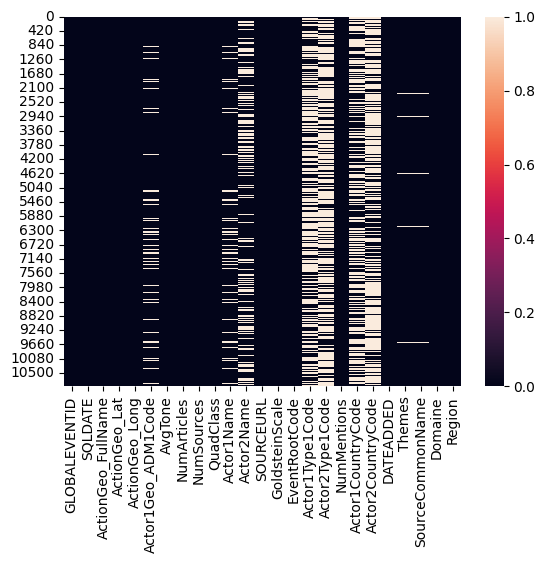

In [839]:
# graphiques des valeurs manquantes
sns.heatmap(data_final.isna())

In [840]:
# Detail sur les variables entières
data_final.describe(include = np.number)

,GLOBALEVENTID,SQLDATE,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,GoldsteinScale,EventRootCode,NumMentions,DATEADDED
count,1.089500e+04,1.089500e+04,10895.000000,10895.000000,10895.000000,10895.000000,10895.000000,10895.000000,10895.000000,10895.000000,10895.000000,1.089500e+04
mean,1.252052e+09,2.025069e+07,9.437320,2.254743,-1.362342,6.812666,1.010188,1.782102,0.440285,6.726755,6.967233,2.025071e+13
std,1.955712e+07,3.732094e+02,0.588221,0.157730,4.696880,3.930466,0.132712,1.126264,4.519483,5.513453,4.260812,5.215474e+08
min,1.218370e+09,2.025010e+07,6.293860,0.968912,-18.518519,1.000000,1.000000,1.000000,-10.000000,1.000000,1.000000,2.025010e+13
25%,1.235196e+09,2.025033e+07,9.500000,2.250000,-4.761905,4.000000,1.000000,1.000000,-2.000000,3.000000,4.000000,2.025033e+13
50%,1.252046e+09,2.025071e+07,9.500000,2.250000,-1.111111,8.000000,1.000000,1.000000,1.900000,4.000000,8.000000,2.025072e+13
75%,1.270844e+09,2.025103e+07,9.500000,2.250000,2.123030,10.000000,1.000000,3.000000,3.400000,11.000000,10.000000,2.025103e+13
max,1.299592e+09,2.025123e+07,12.407400,3.694290,19.480519,48.000000,7.000000,4.000000,10.000000,19.000000,48.000000,2.026042e+13


In [841]:
# Detail sur les variables textes
data_final.describe(include=object)

,ActionGeo_FullName,Actor1Geo_ADM1Code,Actor1Name,Actor2Name,SOURCEURL,Actor1Type1Code,Actor2Type1Code,Actor1CountryCode,Actor2CountryCode,Themes,SourceCommonName,Domaine,Region
count,10895,9466,9466,7120,10895,4860,3669,5297,3903,10670,10723,10895,10895
unique,93,170,606,563,6838,28,28,104,104,6446,1049,8,15
top,Benin,BN,BENIN,BENIN,https://guardian.ng/politics/south-south-pdp-s...,GOV,GOV,BEN,BEN,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;TA...,dailypost.ng,Politique & Gouvernance,Afrique de l'Ouest
freq,10134,7836,2863,1792,9,1745,1313,3073,1986,10,770,9891,7073


In [842]:
# vérification des lieux des évènement
print(data_final['ActionGeo_FullName'].value_counts().head(20))

ActionGeo_FullName
Benin                                10134
Ouidah, Atlantique, Benin               80
Abomey, Zou, Benin                      62
Porto-Novo, Qué, Benin                  50
Alibori, Alibori, Benin                 47
Parakou, Borgou, Benin                  35
Malanville, Atakora, Benin              32
Karimama, Alibori, Benin                29
Ganvie, Benin (general), Benin          23
Porga, Atakora, Benin                   22
Natitingou, Atakora, Benin              19
Kalale, Borgou, Benin                   16
Savalou, Collines, Benin                15
Tanguieta, Atakora, Benin               15
Lokossa, Mono, Benin                    14
Djougou, Donga, Benin                   14
Tchaourou, Benin (general), Benin       14
Allada, Benin (general), Benin          14
Ndali, Borgou, Benin                    13
Kandi, Alibori, Benin                   11
Name: count, dtype: int64


In [843]:
# Afficher quelques liens d'articles où ActionGeo_FullName == 'Benin'
# L'objectif est de voir les articles parlant de Benin City
benin_exact = data_final[data_final['ActionGeo_FullName'] == 'Benin']['SOURCEURL'].head(20)
for url in benin_exact:
    print(url)

https://www.africatopsuccess.com/benin-olivier-boko-et-oswald-homeky-condamnes-a-20-ans-de-prison/
https://www.diaridetarragona.com/tarragona/el-jazz-y-el-sol-toman-el-control-de-las-calles-de-tarragona-KP23792338
https://allafrica.com/stories/202509030183.html
https://thesun.ng/edsiec-conducts-by-election-despite-court-order/
https://senego.com/benin-menaces-de-poursuites-judiciaires-contre-les-auteurs-dinvectives-envers-les-autorites-gabonaises_1881178.html
https://www.marica.bg/balgariq/obshtestvo/kmetat-na-topolovgrad-bori-oganq-v-sakar-stqga-se-za-humanitarna-misiq-v-afrika
https://fr.allafrica.com/stories/202512090595.html
https://www.dw.com/fr/sahel-trump-aes-commerce-minerai/a-73776576
https://www.thecable.ng/benin-republic-requested-naf-support-to-dislodge-coup-plotters-says-presidency/
https://www.jamaicaobserver.com/2025/01/08/caribbean-states-benin-mull-troops-symbolic-haiti/
https://www.nationalaccordnewspaper.com/40-suspended-enigie-appeal-to-oba-of-benin-for-clemency/
ht

In [844]:
data_final[data_final['Actor1Geo_ADM1Code']!='BN']['Actor1Geo_ADM1Code'].value_counts().head(10)

,count
Actor1Geo_ADM1Code,
NI37,174
BN00,139
NI,109
BN08,96
NI11,79
BN09,76
BN07,72
BN10,61
NI05,59


In [845]:
# verification des articles où le lieu de Actor 1 est le nigeria
benin_exact = data_final[data_final['Actor1Geo_ADM1Code'] == 'NI37']['SOURCEURL'].head(20)
for url in benin_exact:
    print(url)

https://quicknews-africa.net/uzodinma-apc-plotting-to-take-over-edo-assembly-speaker-alleges/
https://nigerianobservernews.com/2025/05/edo-civil-society-backs-gov-okpebholos-crackdown-on-cultism/
https://nigerianobservernews.com/2025/06/suspected-assassins-killed-one-in-uromi-declare-son-wanted-2/
https://www.nigerianeye.com/2025/12/police-inspector-shot-dead-at-benin.html
https://blueprint.ng/edo-inspector-akors-killers-walking-free-apc-chides-police/
https://www.nigerianeye.com/2025/12/police-inspector-shot-dead-at-benin.html
https://www.premiumtimesng.com/regional/south-south-regional/772729-police-rescue-kidnapped-edo-chief-official.html
https://dailytrust.com/man-50-arrested-over-s3xual-assault-of-15-year-old-girl/
https://dailypost.ng/2025/09/14/police-rescue-kidnap-victim-foil-abduction-attempt-on-benin-lagos-expressway/
https://leadership.ng/nuj-fumes-as-sacked-edo-task-force-leader-attacks-ebs-staff/
https://quicknews-africa.net/court-remands-56-year-old-man-for-sexually-assau

In [846]:
benin_exact = data_final[data_final['Actor1Geo_ADM1Code'] == 'NI37']['SOURCEURL'].sample(20)
for url in benin_exact:
    print(url)

https://dailypost.ng/2025/11/15/police-arrest-21-secondary-school-students-for-alleged-cultism-remand-8-in-prison/
https://thesun.ng/edo-okpebholo-umahi-despair-over-state-of-federal-roads/
https://nigerianobservernews.com/2025/10/edo-dutch-partners-renew-drive-for-sustainable-forest-management-in-okomu/
https://thenewsnigeria.com.ng/2025/04/20/how-obasekis-man-shut-down-edo-agencys-system-to-cripple-c-of-o-issuance-okpebholos-aide/
https://punchng.com/edo-election-tribunal-inec-to-start-calling-witnesses-thursday/
https://thesun.ng/wanep-equips-1500-community-women-with-peacebuilding-skills/
https://www.tell.ng/okpebholo-inaugurates-orbih-led-aau-governing-council-with-charge-to-restore-lost-glory/
https://onlinenigeria.com/stories/70294-its-gods-plan-obaseki-reacts-to-oshiomholes-fall-2.html
https://dailypost.ng/2025/09/17/police-arrest-man-with-arms-ammunition-in-edo/
https://quicknews-africa.net/group-tasks-gov-obaseki-legislature-to-ban-open-grazing-in-edo/
https://nigerianobserve

In [847]:
benin_exact = data_final[data_final['Actor1Geo_ADM1Code'] == 'NI']['SOURCEURL'].sample(20)
for url in benin_exact:
    print(url)

https://www.terradaily.com/reports/Benin_president_says_bulk_of_military_not_behind_failed_coup_999.html
https://www.thecable.ng/jonathan-nigerian-politics-is-about-betrayal-i-witnessed-it-in-2015/
https://www.ghanamma.com/2025/03/03/wagpa-reassures-plans-to-extend-pipeline-to-all-countries-within-ecowas/
https://www.premiumtimesng.com/news/top-news/841405-benin-coup-ecowas-orders-immediate-deployment-of-standby-force.html
https://ecfr.eu/article/when-the-army-comes-knocking-benins-failed-coup-and-west-african-instability/
https://dailypost.ng/2025/11/12/falconets-pip-benin-to-end-wafu-b-u-20-girls-cup-in-style/
https://blueprint.ng/benin-republic-coup-tinubu-writes-senate-seeks-approval-to-deploy-nigerian-troops/
https://www.thehindu.com/news/international/benin-coup-leaders-location-fate-of-hostages-unknown-after-failed-takeover/article70372191.ece
https://www.arise.tv/dutch-government-approves-restitution-of-119-benin-bronzes-to-nigeria/
https://www.spacewar.com/afp/251218150011.vv1

In [848]:
benin_exact = data_final[data_final['Actor1Geo_ADM1Code'] == 'NI11']['SOURCEURL'].sample(20)
for url in benin_exact:
    print(url)

https://punchng.com/benin-ecowas-fears-coup-surge-senate-okays-nigerian-troops-deployment/
https://www.mediacongo.net/article-actualite-158626_coup_d_etat_dejoue_au_benin_pourquoi_le_nigeria_a_vole_au_secours_de_patrice_talon.html
https://naija247news.com/nigeria-senate-approves-tinubus-deployment-of-troops-to-foil-benin-coup-attempt/
https://www.theglobeandmail.com/world/article-netherlands-to-return-119-benin-bronzes-to-nigeria-dutch-embassy-in/
https://www.premiumtimesng.com/regional/south-south-regional/824247-lp-chairperson-social-media-influencer-clash-at-abuja-airport.html
https://naija247news.com/nigeria-senate-approves-tinubus-deployment-of-troops-to-foil-benin-coup-attempt/
https://www.afriquejet.com/actus/243-outils-multimedias-pour-la-visibilite.html
https://dailypost.ng/2025/12/08/they-made-us-proud-tinubu-hails-nigerian-military-for-protecting-democracy-in-benin/
https://www.peoplesdailyng.com/edo-election-tribunal-help-your-brother-gov-okpebholo-to-succeed/
https://www.t

# Détection du bruit

In [849]:
# Définition de la target intermédiaire
data_final['crisis'] = data_final['QuadClass'].isin([3,4]).astype(int)

In [850]:
# Distribution de la variable cible AVANT nettoyage

crisis_counts = data_final["crisis"].value_counts()
crisis_rate = data_final["crisis"].mean() * 100

print("Répartition :")
print(crisis_counts)

print(f"\nTaux de crise global : {crisis_rate:.2f}%")

Répartition :
crisis
0    7990
1    2905
Name: count, dtype: int64

Taux de crise global : 26.66%


In [851]:
#aperçu des valeurs crise en pourcentage
data_final["crisis"].value_counts(normalize=True) * 100

,proportion
crisis,
0,73.336393
1,26.663607


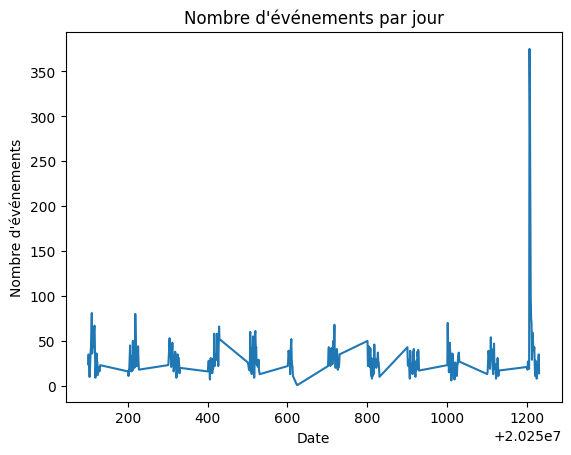

In [852]:
# volume d'evenement par jour
daily_events = data_final.groupby('SQLDATE').size()
daily_events.plot(title="Nombre d'événements par jour")
plt.xlabel("Date")
plt.ylabel("Nombre d'événements")
plt.show()

In [853]:
daily_events.sort_values(ascending=False).head(10)

,0
SQLDATE,
20251207,375
20251208,315
20251209,209
20251210,99
20250110,81
20250219,80
20251211,75
20251002,70
20251212,70


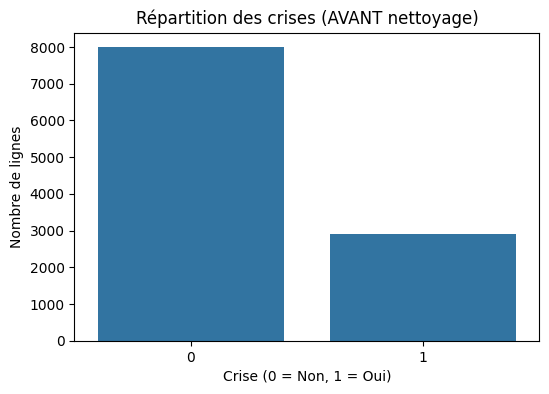

In [854]:
plt.figure(figsize=(6,4))
sns.countplot(data=data_final, x="crisis")

plt.title("Répartition des crises (AVANT nettoyage)")
plt.xlabel("Crise (0 = Non, 1 = Oui)")
plt.ylabel("Nombre de lignes")

plt.show()

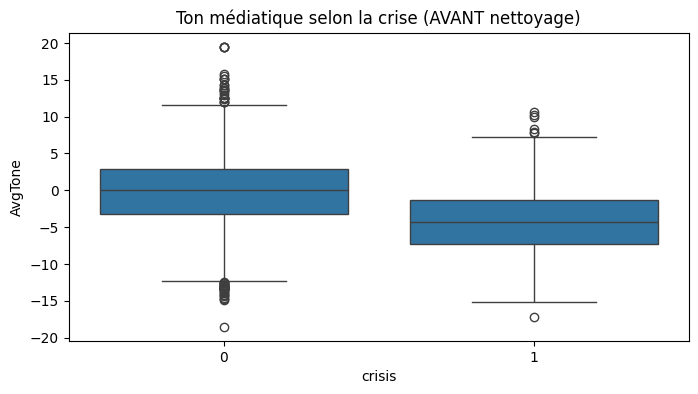

In [855]:
plt.figure(figsize=(8,4))
sns.boxplot(data=data_final, x="crisis", y="AvgTone")

plt.title("Ton médiatique selon la crise (AVANT nettoyage)")
plt.show()

On observe que les événements classés comme crise présentent un ton médiatique
globalement plus négatif que les événements non critiques.

La médiane du ton pour les crises est significativement inférieure,
ce qui indique une corrélation entre négativité du discours médiatique
et présence d’une crise.

Cependant, la présence de chevauchements entre les distributions montre
que cette variable seule ne permet pas de distinguer parfaitement les crises.

In [856]:
#valeurs possibles pouvant etre du bruit
text_cols = [
    "ActionGeo_FullName",
    "Actor1Name",
    "Actor2Name",
    "SOURCEURL",
    "Themes",
    "SourceCommonName"
]

data_final["combined_text"] = data_final[text_cols].fillna("").agg(" ".join, axis=1).str.lower()

data_final["is_possible_benin_city_noise"] = data_final["combined_text"].str.contains(
    "benin city|edo|oba of benin|benincity",
    case=False,
    na=False
)

data_final["is_possible_benin_city_noise"].value_counts()

,count
is_possible_benin_city_noise,
False,6189
True,4706


In [857]:
noise_rate = data_final["is_possible_benin_city_noise"].mean() * 100
print(f"Part des lignes potentiellement liées à Benin City ou Edo State et donc potentiellement hors sujet: {noise_rate:.2f}%")

Part des lignes potentiellement liées à Benin City ou Edo State et donc potentiellement hors sujet: 43.19%


In [858]:
# On sépare le dataset en deux parties :
# 1. df_clean : lignes qui semblent réellement concerner le pays Bénin
# 2. df_noise : lignes qui semblent plutôt liées à Benin City / Edo / Nigeria

df_clean = data_final[data_final["is_possible_benin_city_noise"] == False].copy()
df_noise = data_final[data_final["is_possible_benin_city_noise"] == True].copy()

# Vérification des tailles
print("Nombre total de lignes :", len(data_final))
print("Nombre de lignes probablement liées au pays Bénin :", len(df_clean))
print("Nombre de lignes potentiellement hors sujet :", len(df_noise))

Nombre total de lignes : 10895
Nombre de lignes probablement liées au pays Bénin : 6189
Nombre de lignes potentiellement hors sujet : 4706


In [859]:
# Ici on compare le taux de crise dans :
# - le dataset complet
# - les données probablement liées au pays Bénin
# - les données potentiellement hors sujet

global_crisis_rate = data_final["crisis"].mean() * 100
clean_crisis_rate = df_clean["crisis"].mean() * 100
noise_crisis_rate = df_noise["crisis"].mean() * 100

print(f"Taux de crise global : {global_crisis_rate:.2f}%")
print(f"Taux de crise dans les données Bénin probable : {clean_crisis_rate:.2f}%")
print(f"Taux de crise dans les données hors sujet possibles : {noise_crisis_rate:.2f}%")

Taux de crise global : 26.66%
Taux de crise dans les données Bénin probable : 23.95%
Taux de crise dans les données hors sujet possibles : 30.24%


In [860]:
#tableau de synthèse pour comparer les deux groupes

comparison_table = pd.DataFrame({
    "Catégorie": ["Bénin probable", "Hors sujet possible"],
    "Nombre de lignes": [len(df_clean), len(df_noise)],
    "Part du dataset (%)": [
        len(df_clean) / len(data_final) * 100,
        len(df_noise) / len(data_final) * 100
    ],
    "Taux de crise (%)": [
        df_clean["crisis"].mean() * 100,
        df_noise["crisis"].mean() * 100
    ],
    "AvgTone moyen": [
        df_clean["AvgTone"].mean(),
        df_noise["AvgTone"].mean()
    ],
    "GoldsteinScale moyen": [
        df_clean["GoldsteinScale"].mean(),
        df_noise["GoldsteinScale"].mean()
    ]
})

comparison_table

,Catégorie,Nombre de lignes,Part du dataset (%),Taux de crise (%),AvgTone moyen,GoldsteinScale moyen
0,Bénin probable,6189,56.805874,23.945710,-0.929924,0.800016
1,Hors sujet possible,4706,43.194126,30.237994,-1.931028,-0.032809


In [861]:
# pour alle rplus loin on compte précisément combien de lignes contiennent certains mots-clés
# ça  permet de montrer concrètement pourquoi certaines lignes sont considérées comme du bruit

keywords = {
    "Benin City": "benin city",
    "Edo": "edo",
    "Nigeria": "nigeria",
    "Lagos": "lagos",
    "Abuja": "abuja"
}

keyword_results = []

for label, keyword in keywords.items():
    count = data_final["combined_text"].str.contains(keyword, case=False, na=False).sum()
    percentage = count / len(data_final) * 100

    keyword_results.append({
        "Mot-clé": label,
        "Nombre de lignes": count,
        "Part du dataset (%)": percentage
    })

keyword_counts_df = pd.DataFrame(keyword_results)

keyword_counts_df.sort_values(by="Nombre de lignes", ascending=False)



,Mot-clé,Nombre de lignes,Part du dataset (%)
1,Edo,4628,42.478201
2,Nigeria,2166,19.880679
0,Benin City,446,4.093621
4,Abuja,93,0.853603
3,Lagos,70,0.642497


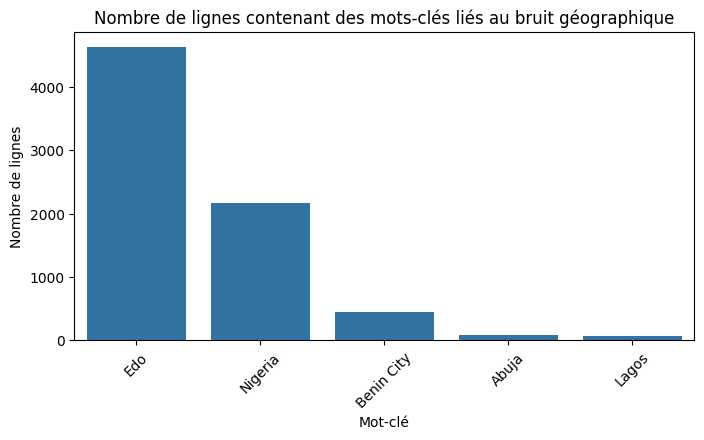

In [862]:
# Visualisation des mots-clés qui indiquent un possible bruit géographique

keyword_counts_df_sorted = keyword_counts_df.sort_values(
    by="Nombre de lignes",
    ascending=False
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=keyword_counts_df_sorted,
    x="Mot-clé",
    y="Nombre de lignes"
)

plt.title("Nombre de lignes contenant des mots-clés liés au bruit géographique")
plt.xlabel("Mot-clé")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)
plt.show()

In [863]:
data_final["has_edo"] = data_final["combined_text"].str.contains("edo", case=False, na=False)
data_final["has_nigeria"] = data_final["combined_text"].str.contains("nigeria", case=False, na=False)
data_final["has_benin_city"] = data_final["combined_text"].str.contains("benin city", case=False, na=False)

# Combinaisons
pd.crosstab(data_final["has_edo"], data_final["has_nigeria"])

has_nigeria,False,True
has_edo,,
False,5373,894
True,3356,1272


Certaines lignes contiennent simultanément ‘Edo’, ‘Nigeria’ et ‘Benin City’, ce qui confirme que ces événements concernent le Nigeria et non le Bénin, mais sont mal interprétés à cause du nom ‘Benin’. Une même information peut contenir plusieurs indicateurs géographiques comme ‘Edo’, ‘Nigeria’ et ‘Benin City’.
et même lorsque le mot ‘Nigeria’ n’est pas présent, la mention ‘Edo’ seule représente déjà plus de 3000 lignes, ce qui montre que le bruit est sous-estimé si l’on ne considère qu’un seul indicateur

L’analyse croisée des mots-clés "Edo" et "Nigeria" révèle que :

- 5373 lignes ne contiennent aucun des deux mots-clés et son des données qu'on peut juger fiables
- 3356 lignes contiennent uniquement "Edo" qui sont des bruits cachés
-et 1272 lignes contiennent à la fois "Edo" et "Nigeria" où le bruit est confirmé

In [864]:
#stocker les indicateurs de bruit
data_final["nb_keywords"] = (
    data_final["has_edo"].astype(int) +
    data_final["has_nigeria"].astype(int) +
    data_final["has_benin_city"].astype(int)
)

data_final["nb_keywords"].value_counts()
data_final["noise_level"] = data_final["nb_keywords"]

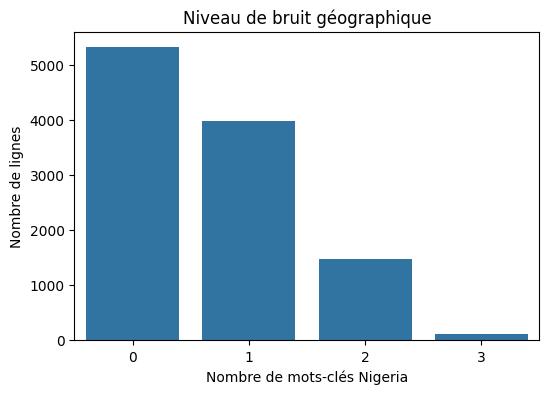

In [865]:

plt.figure(figsize=(6,4))
sns.countplot(data=data_final, x="nb_keywords")

plt.title("Niveau de bruit géographique")
plt.xlabel("Nombre de mots-clés Nigeria")
plt.ylabel("Nombre de lignes")

plt.show()

### Interprétation du graphique

Ce graphique représente la distribution du nombre de mots-clés liés au Nigeria
présents dans chaque ligne du dataset.

- 0 : aucune mention → données probablement fiables
- 1 : une mention → données ambiguës
- 2 ou 3 : plusieurs mentions → données fortement bruitées

On observe que plus de la moitié des données contiennent au moins un mot-clé,
ce qui confirme toujours la présence d’un bruit géographique important dans le dataset.

In [866]:
# Cette variable indique si une ligne semble fiable pour analyser le pays Bénin.
# True = probablement lié au pays Bénin
# False = potentiellement lié à Benin City / Edo / Nigeria

data_final["is_benin_reliable"] = ~data_final["is_possible_benin_city_noise"]

# Vérification
data_final["is_benin_reliable"].value_counts()

,count
is_benin_reliable,
True,6189
False,4706


In [867]:
data_final["noise_category"] = pd.cut(
    data_final["noise_level"],
    bins=[-1, 0, 1, 3],
    labels=["Propre", "Ambigu", "Bruité"]
)

data_final["noise_category"].value_counts()

,count
noise_category,
Propre,5333
Ambigu,3989
Bruité,1573


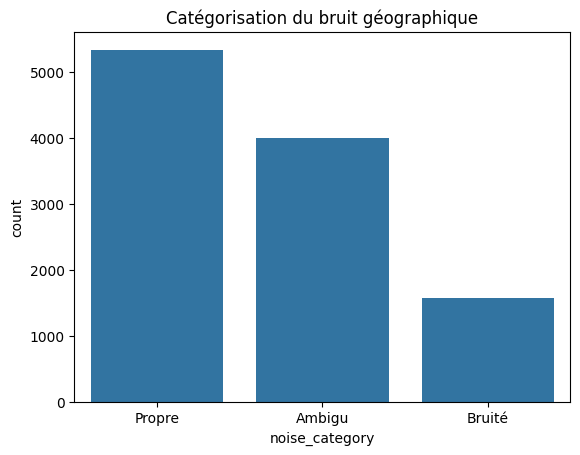

In [868]:
sns.countplot(data=data_final, x="noise_category")
plt.title("Catégorisation du bruit géographique")
plt.show()

Analyse du bruit

In [869]:
# On regarde le taux de crise selon le niveau de bruit

noise_crisis = data_final.groupby("nb_keywords")["crisis"].mean() * 100
noise_crisis

,crisis
nb_keywords,
0,23.457716
1,32.063174
2,24.114441
3,20.000000


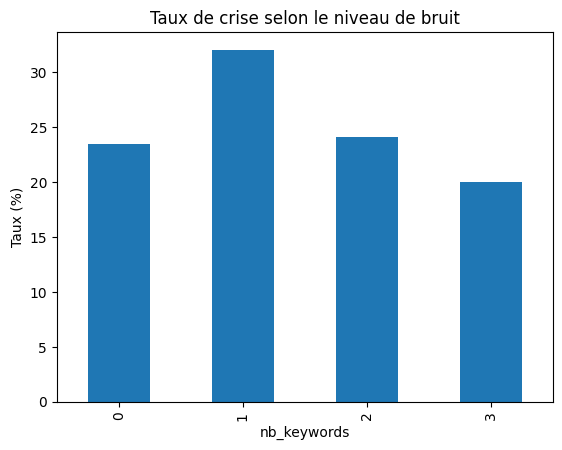

In [870]:
noise_crisis.plot(kind="bar")
plt.title("Taux de crise selon le niveau de bruit")
plt.ylabel("Taux (%)")
plt.show()

On observe que les données contenant un seul mot-clé lié au Nigeria
présentent le taux de crise le plus élevé (~32%).

Cela suggère que les données légèrement bruitées peuvent biaiser
l’analyse en surreprésentant les situations de crise.

À l’inverse, les données fortement bruitées (2 ou 3 mots-clés)
semblent moins pertinentes et plus aléatoires.

Cela justifie le choix de supprimer toutes les données contenant
au moins un mot-clé afin d’éviter ce biais.

In [871]:
data_final.head()

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,Actor1Geo_ADM1Code,AvgTone,NumArticles,NumSources,QuadClass,...,crisis,combined_text,is_possible_benin_city_noise,has_edo,has_nigeria,has_benin_city,nb_keywords,noise_level,is_benin_reliable,noise_category
0,1223715366,20250130,Benin,9.5,2.25,BN,-10.909091,10,1,4,...,1,benin lawyer https://www.africatopsuccess.com...,False,False,False,False,0,0,True,Propre
1,1240196709,20250425,Benin,9.5,2.25,NaN,4.375000,10,1,2,...,0,benin benin https://www.diaridetarragona.com/...,False,False,False,False,0,0,True,Propre
2,1261053214,20250903,Benin,9.5,2.25,NaN,-2.040816,10,1,1,...,0,benin companies https://allafrica.com/stories...,False,False,False,False,0,0,True,Propre
3,1264285691,20250920,Benin,9.5,2.25,BN,-3.571429,10,1,4,...,1,benin political parties https://thesun.ng/eds...,True,True,False,False,1,1,False,Ambigu
4,1265170956,20250925,Benin,9.5,2.25,BN,-2.424242,10,1,1,...,0,benin benin https://senego.com/benin-menaces-...,False,False,False,False,0,0,True,Propre


#NETTOYAGE DES DONNES

In [872]:
mots_nigerians = 'benin city|edo|oba of benin|benincity|lagos|nigeria'
def data_cleaning (data) :
    # suppression des lignes dupliquées
    data = data.drop_duplicates(subset='GLOBALEVENTID').copy()
    # suppession des variables avec trop de NaN
    data.drop(columns=['Actor1Type1Code', 'Actor2Type1Code',
                       'Actor1CountryCode', 'Actor2CountryCode', 'Actor1Geo_ADM1Code'],
              inplace=True)
    # Gestion des autres NaN
    data['Actor1Name'] = data['Actor1Name'].fillna("Unknown")
    data['Actor2Name'] = data['Actor2Name'].fillna("Unknown")
    data['SourceCommonName'] = data['SourceCommonName'].fillna("Unknown")
    # La ligne suivante a été commentée car la colonne 'Themes' a été supprimée précédemment.
    data['Themes'] = data['Themes'].fillna("")
    # suppression des articles de Benin City evidents
    data = data[~data['SOURCEURL'].str.contains(mots_nigerians, case=False, na=False)]
    # Date
    data['SQLDATE'] = pd.to_datetime(data['SQLDATE'], format='%Y%m%d')

      # suppression des colonnes intermédiaires
    colonnes_a_supprimer = [
        "has_benin",
        "has_nigeria",
        "has_benin_city",
        "has_edo",
        "nb_keywords",
        "noise_level",
        "is_reliable_benin",
        "is_possible_benin_city_noise",
        "is_benin_reliable",
        "noise_category",
        "combined_text"
    ]

    data.drop(columns=colonnes_a_supprimer, errors="ignore", inplace=True)
    return data


In [873]:
data= data_cleaning(data_final)

In [874]:
data.head()

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,SOURCEURL,GoldsteinScale,EventRootCode,NumMentions,DATEADDED,Themes,SourceCommonName,Domaine,Region,crisis
0,1223715366,2025-01-30,Benin,9.5,2.25,-10.909091,10,1,4,LAWYER,...,https://www.africatopsuccess.com/benin-olivier...,-8.0,16,10,20250130184500,ARREST;SOC_POINTSOFINTEREST;SOC_POINTSOFINTERE...,africatopsuccess.com,Politique & Gouvernance,Panafricain,1
1,1240196709,2025-04-25,Benin,9.5,2.25,4.375000,10,1,2,Unknown,...,https://www.diaridetarragona.com/tarragona/el-...,6.4,6,10,20250425210000,EPU_CATS_MIGRATION_FEAR_FEAR;UNGP_FORESTS_RIVE...,diaridetarragona.com,Sécurité & Conflit,Europe,0
2,1261053214,2025-09-03,Benin,9.5,2.25,-2.040816,10,1,1,Unknown,...,https://allafrica.com/stories/202509030183.html,5.2,3,10,20250903110000,EPU_ECONOMY;EPU_ECONOMY_HISTORIC;WB_2024_ANTI_...,allafrica.com,Politique & Gouvernance,Panafricain,0
3,1264285691,2025-09-20,Benin,9.5,2.25,-3.571429,10,1,4,POLITICAL PARTIES,...,https://thesun.ng/edsiec-conducts-by-election-...,-8.0,16,10,20250920233000,EPU_POLICY;EPU_POLICY_POLITICAL;ECON_BOYCOTT;T...,thesun.ng,Politique & Gouvernance,Afrique de l'Ouest,1
4,1265170956,2025-09-25,Benin,9.5,2.25,-2.424242,10,1,1,BENIN,...,https://senego.com/benin-menaces-de-poursuites...,5.2,3,10,20250925141500,WB_696_PUBLIC_SECTOR_MANAGEMENT;WB_840_JUSTICE...,senego.com,Politique & Gouvernance,Afrique de l'Ouest,0


In [875]:
data.isna().sum()

,0
GLOBALEVENTID,0
SQLDATE,0
ActionGeo_FullName,0
ActionGeo_Lat,0
ActionGeo_Long,0
AvgTone,0
NumArticles,0
NumSources,0
QuadClass,0
Actor1Name,0


In [876]:
data.shape

(7255, 21)

In [877]:
# sauvegarde des données nétoyées
data.to_csv('database_clean.csv', index = False)

In [878]:
Décommentez cettte ligne si vous souhaitez télécharger les données directmeent

#from google.colab import files
#files.download("database_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [879]:
df = pd.read_csv("database_clean.csv")
df.head()

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,SOURCEURL,GoldsteinScale,EventRootCode,NumMentions,DATEADDED,Themes,SourceCommonName,Domaine,Region,crisis
0,1223715366,2025-01-30,Benin,9.5,2.25,-10.909091,10,1,4,LAWYER,...,https://www.africatopsuccess.com/benin-olivier...,-8.0,16,10,20250130184500,ARREST;SOC_POINTSOFINTEREST;SOC_POINTSOFINTERE...,africatopsuccess.com,Politique & Gouvernance,Panafricain,1
1,1240196709,2025-04-25,Benin,9.5,2.25,4.375000,10,1,2,Unknown,...,https://www.diaridetarragona.com/tarragona/el-...,6.4,6,10,20250425210000,EPU_CATS_MIGRATION_FEAR_FEAR;UNGP_FORESTS_RIVE...,diaridetarragona.com,Sécurité & Conflit,Europe,0
2,1261053214,2025-09-03,Benin,9.5,2.25,-2.040816,10,1,1,Unknown,...,https://allafrica.com/stories/202509030183.html,5.2,3,10,20250903110000,EPU_ECONOMY;EPU_ECONOMY_HISTORIC;WB_2024_ANTI_...,allafrica.com,Politique & Gouvernance,Panafricain,0
3,1264285691,2025-09-20,Benin,9.5,2.25,-3.571429,10,1,4,POLITICAL PARTIES,...,https://thesun.ng/edsiec-conducts-by-election-...,-8.0,16,10,20250920233000,EPU_POLICY;EPU_POLICY_POLITICAL;ECON_BOYCOTT;T...,thesun.ng,Politique & Gouvernance,Afrique de l'Ouest,1
4,1265170956,2025-09-25,Benin,9.5,2.25,-2.424242,10,1,1,BENIN,...,https://senego.com/benin-menaces-de-poursuites...,5.2,3,10,20250925141500,WB_696_PUBLIC_SECTOR_MANAGEMENT;WB_840_JUSTICE...,senego.com,Politique & Gouvernance,Afrique de l'Ouest,0


In [880]:
print("Shape :", df.shape)
df.info()

Shape : (7255, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7255 entries, 0 to 7254
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GLOBALEVENTID       7255 non-null   int64  
 1   SQLDATE             7255 non-null   object 
 2   ActionGeo_FullName  7255 non-null   object 
 3   ActionGeo_Lat       7255 non-null   float64
 4   ActionGeo_Long      7255 non-null   float64
 5   AvgTone             7255 non-null   float64
 6   NumArticles         7255 non-null   int64  
 7   NumSources          7255 non-null   int64  
 8   QuadClass           7255 non-null   int64  
 9   Actor1Name          7255 non-null   object 
 10  Actor2Name          7255 non-null   object 
 11  SOURCEURL           7255 non-null   object 
 12  GoldsteinScale      7255 non-null   float64
 13  EventRootCode       7255 non-null   int64  
 14  NumMentions         7255 non-null   int64  
 15  DATEADDED           7255 non-null   

In [881]:
# Valeurs manquantes par colonne
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
Themes,214


In [882]:
# Vérification des doublons complets
print("Nombre de lignes totalement dupliquées :", df.duplicated().sum())

# Si la colonne GLOBALEVENTID existe, on vérifie aussi les doublons d'événements
if "GLOBALEVENTID" in df.columns:
    print("Doublons sur GLOBALEVENTID :", df.duplicated(subset=["GLOBALEVENTID"]).sum())

Nombre de lignes totalement dupliquées : 0
Doublons sur GLOBALEVENTID : 0


In [883]:
# Conversion de la date.
# Certains exports GDELT ont SQLDATE au format 20250101, d'autres déjà au format date.
if not np.issubdtype(df["SQLDATE"].dtype, np.datetime64):
    df["SQLDATE"] = pd.to_datetime(df["SQLDATE"], errors="coerce")

# Variables temporelles utiles pour l'EDA et le futur modèle
# Elles permettront d'analyser les tendances par mois, semaine et jour.
df["year"] = df["SQLDATE"].dt.year
df["month"] = df["SQLDATE"].dt.month
df["week"] = df["SQLDATE"].dt.isocalendar().week.astype(int)
df["dayofweek"] = df["SQLDATE"].dt.dayofweek

# Si la variable crisis n'existe pas, on la crée à partir de QuadClass.
# 1 = crise ; 0 = non crise.
if "crisis" not in df.columns:
    df["crisis"] = df["QuadClass"].isin([3, 4]).astype(int)

# Vérification
df[["SQLDATE", "year", "month", "week", "dayofweek", "QuadClass", "crisis"]].head()

,SQLDATE,year,month,week,dayofweek,QuadClass,crisis
0,2025-01-30,2025,1,5,3,4,1
1,2025-04-25,2025,4,17,4,2,0
2,2025-09-03,2025,9,36,2,1,0
3,2025-09-20,2025,9,38,5,4,1
4,2025-09-25,2025,9,39,3,1,0


#COMPARAISON AVANT-APRES NETTOYAGE

In [884]:
clean_crisis_rate = df["crisis"].mean() * 100

print(f"Taux de crise après nettoyage : {clean_crisis_rate:.2f}%")

Taux de crise après nettoyage : 24.65%


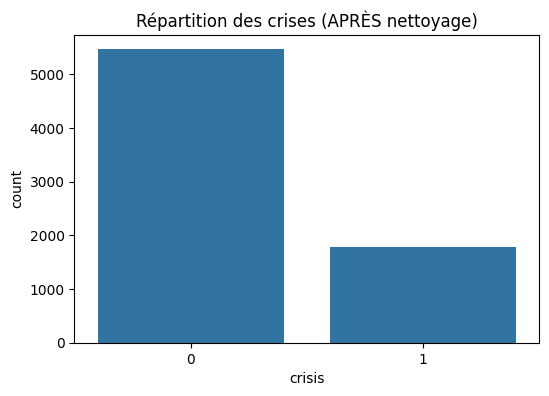

In [885]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="crisis")

plt.title("Répartition des crises (APRÈS nettoyage)")
plt.show()

In [886]:
comparison = pd.DataFrame({
    "Dataset": ["Avant nettoyage", "Après nettoyage"],
    "Taux de crise (%)": [
        data_final["crisis"].mean() * 100,
        df["crisis"].mean() * 100
    ]
})

comparison

,Dataset,Taux de crise (%)
0,Avant nettoyage,26.663607
1,Après nettoyage,24.645072


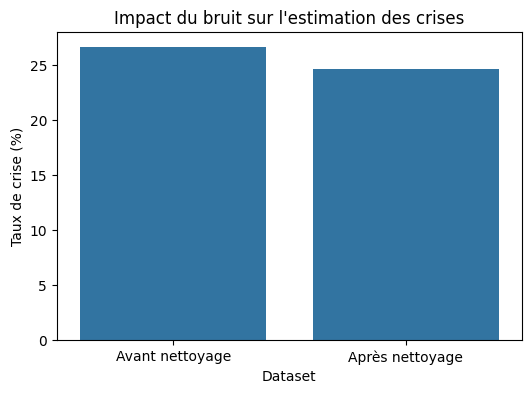

In [887]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Dataset", y="Taux de crise (%)")

plt.title("Impact du bruit sur l'estimation des crises")
plt.show()

In [888]:
bias = (data_final["crisis"].mean() - df["crisis"].mean()) / df_clean["crisis"].mean() * 100


print(f"Le bruit introduit une surestimation des crises de {bias:.2f}%")

Le bruit introduit une surestimation des crises de 8.43%


In [889]:
df["crisis"].value_counts()

,count
crisis,
0,5467
1,1788


In [890]:
#test avec le ton
print("Avant nettoyage :", data_final.groupby("crisis")["AvgTone"].mean())
print("Après nettoyage :", df.groupby("crisis")["AvgTone"].mean())

Avant nettoyage : crisis
0   -0.324102
1   -4.217949
Name: AvgTone, dtype: float64
Après nettoyage : crisis
0   -0.087867
1   -3.909843
Name: AvgTone, dtype: float64


On observe une baisse du taux de crise après nettoyage des données
(26.66% → 24.64%).

Cela montre que le bruit géographique introduit une légère surestimation des crises.

Bien que la différence absolue semble faible (~2 points),
elle représente une surestimation relative d’environ 8%,
ce qui est significatif dans un contexte d’analyse.

Toutefois, après nettoyage des données, le taux de crise reste significatif (~25%). ça montre que les événements liés au Bénin incluent effectivement des situations de crise sur la période sélectionnée


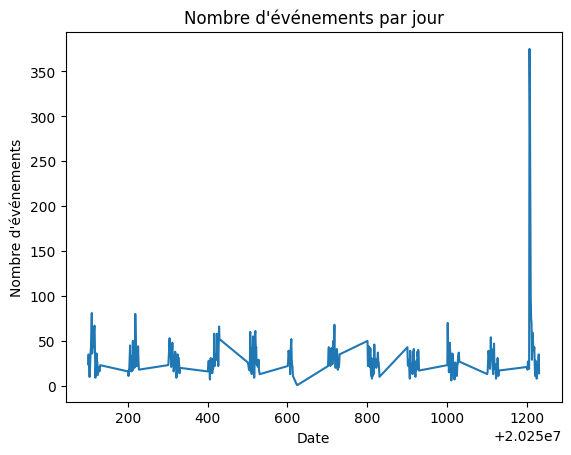

In [891]:
# volume d'evenement par jour
daily_events_clean = df.groupby('SQLDATE').size()
daily_events.plot(title="Nombre d'événements par jour")
plt.xlabel("Date")
plt.ylabel("Nombre d'événements")
plt.show()

In [892]:
daily_events_clean.sort_values(ascending=False).head(10)

,0
SQLDATE,
2025-12-07,331
2025-12-08,257
2025-12-09,145
2025-12-10,85
2025-01-10,58
2025-04-24,56
2025-12-12,55
2025-01-12,51
2025-12-11,50


Le graphique montre que les crises ne sont pas réparties de manière uniforme,
mais qu’elles sont fortement concentrées sur une période précise, allant du 7 au 10 décembre 2025.

En observant de plus près ces dates, on constate qu’elles correspondent
effectivement à la période autour de la tentative de coup d’État au Bénin.

# TEST

Après avoir généré le nouveau fichier, par cuiriosité nous avons essayé de voir si nous pouvions faire un tri entre des données qui contiennent Nigéria mais qui peuvent etre potentiellement reliées au Bénin. Et effectivement, même si légère nous avons une différence entre le nombre de données

df.to_csv("nouvelle_base.csv", index=False)
from google.colab import files
files.download("df.csv")

In [893]:
print("Shape du dataset :", df.shape)

Shape du dataset : (7255, 25)


In [894]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 7255
Nombre de colonnes : 25


In [895]:
df.describe()

,GLOBALEVENTID,SQLDATE,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,GoldsteinScale,EventRootCode,NumMentions,DATEADDED,crisis,year,month,week,dayofweek
count,7.255000e+03,7255,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7.255000e+03,7255.000000,7255.0,7255.000000,7255.000000,7255.000000
mean,1.252579e+09,2025-07-11 23:27:26.919366144,9.405935,2.256338,-1.029795,7.380841,1.011578,1.735768,0.716733,6.561819,7.555203,2.025071e+13,0.246451,2025.0,6.891523,27.963060,2.777533
min,1.218370e+09,2025-01-01 00:00:00,6.293860,0.968912,-18.518519,1.000000,1.000000,1.000000,-10.000000,1.000000,1.000000,2.025010e+13,0.000000,2025.0,1.000000,1.000000,0.000000
25%,1.234868e+09,2025-03-28 00:00:00,9.500000,2.250000,-4.164040,4.000000,1.000000,1.000000,-2.000000,3.000000,4.000000,2.025033e+13,0.000000,2025.0,3.000000,13.000000,1.000000
50%,1.252315e+09,2025-07-15 00:00:00,9.500000,2.250000,-0.771208,10.000000,1.000000,1.000000,1.900000,4.000000,10.000000,2.025072e+13,0.000000,2025.0,7.000000,29.000000,3.000000
75%,1.273203e+09,2025-11-08 00:00:00,9.500000,2.250000,2.325581,10.000000,1.000000,2.000000,3.400000,9.000000,10.000000,2.025111e+13,0.000000,2025.0,11.000000,45.000000,4.000000
max,1.299592e+09,2025-12-31 00:00:00,12.407400,3.694290,19.480519,48.000000,7.000000,4.000000,10.000000,19.000000,48.000000,2.026042e+13,1.000000,2025.0,12.000000,52.000000,6.000000
std,2.010340e+07,NaN,0.699415,0.177918,4.583502,4.038257,0.143332,1.092526,4.502242,5.318139,4.412518,4.851183e+08,0.430974,0.0,3.844324,16.645554,1.995754


In [896]:
df["crisis"].value_counts()

,count
crisis,
0,5467
1,1788


In [897]:
# Mots-clés qui indiquent clairement le pays Bénin
# On évite de se baser uniquement sur "benin", car cela peut aussi venir de "Benin City"
df["combined_text"] = df[text_cols].fillna("").agg(" ".join, axis=1).str.lower()
df["has_edo"] = df["combined_text"].str.contains("edo", case=False, na=False)
df["has_nigeria"] = df["combined_text"].str.contains("nigeria", case=False, na=False)
df["has_benin_city"] = df["combined_text"].str.contains("benin city", case=False, na=False)

df["has_benin_country"] = df["combined_text"].str.contains(
    "benin republic|republic of benin|cotonou|porto-novo|porto novo|parakou|"
    "abomey|calavi|natitingou|ouidah|bohicon|lokossa|djougou|"
    "government of benin|benin government|president of benin",
    case=False,
    na=False
)

In [898]:
df["is_reliable_benin"] = (
    # pas de bruit fort sur le Nigeria
    (df["has_edo"] == False) &
    (df["has_benin_city"] == False) &

    # ET
    (
        # soit pas Nigeria du tout
        (df["has_nigeria"] == False) |

        # soit Nigeria mais mention claire du Bénin
        (
            (df["has_nigeria"] == True) &
            (df["has_benin_country"] == True)
        )
    )
)

In [899]:
df["is_reliable_benin"].value_counts()

,count
is_reliable_benin,
True,5316
False,1939


In [900]:
df[df["is_reliable_benin"] == True].head()

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,year,month,week,dayofweek,combined_text,has_edo,has_nigeria,has_benin_city,has_benin_country,is_reliable_benin
0,1223715366,2025-01-30,Benin,9.5,2.25,-10.909091,10,1,4,LAWYER,...,2025,1,5,3,benin lawyer unknown https://www.africatopsucc...,False,False,False,False,True
1,1240196709,2025-04-25,Benin,9.5,2.25,4.375000,10,1,2,Unknown,...,2025,4,17,4,benin unknown benin https://www.diaridetarrago...,False,False,False,False,True
2,1261053214,2025-09-03,Benin,9.5,2.25,-2.040816,10,1,1,Unknown,...,2025,9,36,2,benin unknown companies https://allafrica.com/...,False,False,False,False,True
4,1265170956,2025-09-25,Benin,9.5,2.25,-2.424242,10,1,1,BENIN,...,2025,9,39,3,benin benin unknown https://senego.com/benin-m...,False,False,False,False,True
5,1256003927,2025-08-06,Benin,9.5,2.25,1.476015,6,1,2,AFRICA,...,2025,8,32,2,benin africa unknown https://www.marica.bg/bal...,False,False,False,False,True


In [901]:
df["has_benin"] = df["combined_text"].str.contains(
    "benin republic|cotonou|porto-novo|benin government",
    case=False,
    na=False
)

df[(df["has_benin"] == True) & (df["has_benin_city"] == False)].head()

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,month,week,dayofweek,combined_text,has_edo,has_nigeria,has_benin_city,has_benin_country,is_reliable_benin,has_benin
17,1261240619,2025-09-04,Benin,9.50000,2.25000,-8.592322,10,1,4,GOVERNMENT,...,9,36,3,benin government army https://allafrica.com/st...,True,False,False,True,False,True
24,1245669914,2025-05-23,Benin,9.50000,2.25000,-2.887139,5,1,1,GOVERNMENT,...,5,21,4,benin government unknown https://dailypost.ng/...,False,False,False,True,True,True
25,1278305493,2025-12-09,Benin,9.50000,2.25000,-4.308094,3,1,2,GOVERNMENT,...,12,50,1,benin government ivorian https://www.myjoyonli...,True,False,False,True,False,True
48,1278095265,2025-12-07,Benin,9.50000,2.25000,-3.092784,10,1,2,GOVERNMENT,...,12,49,6,benin government army https://www.tu.no/nyhets...,False,False,False,True,True,True
50,1244168236,2025-05-16,"Abomey, Zou, Benin",7.18286,1.99119,2.534562,10,1,1,BENIN,...,5,20,4,"abomey, zou, benin benin government https://le...",False,False,False,True,True,True


In [902]:
# lignes qui mentionnent Nigeria et  Bénin

df_nigeria_benin = df[
    (df["has_nigeria"] == True) &
    (df["has_benin_country"] == True)
]

print("Nombre de lignes mentionnant Nigeria + Bénin :", len(df_nigeria_benin))

Nombre de lignes mentionnant Nigeria + Bénin : 11


In [903]:
# lignes qui mentionnent Edo et  Bénin

df_nigeria_benin = df[
    (df["has_benin"] == True) &
    (df["has_edo"] == True)
]

print("Nombre de lignes mentionnant Nigeria + Bénin :", len(df_nigeria_benin))

Nombre de lignes mentionnant Nigeria + Bénin : 98


Nous remarquons qu'il y a encore quelques lignes mentionnant 3Edo", mais vu qu'elle ne représentent qu'une petite partie du dataset, nous poursuivons notre analyse sur les données exportées, et allons reovir ça de plus près si nous avons la chance de poursuivre l'aventure ;)